In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import statsmodels.api as st
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

#Lifelines is a survival analysis package
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test   
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter

In [6]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [7]:
df.shape

(299, 13)

First 5 rows:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  smoking  time  DEATH_EVENT
0  75.0        0                       582         0                 20                    1  265000.00               1.9           130    1        0     4            1
1  55.0        0                      7861         0                 38                    0  263358.03               1.1           136    1        0     6            1
2  65.0        0                       146         0                 20                    0  162000.00               1.3           129    1        1     7            1
3  50.0        1                       111         0                 20                    0  210000.00               1.9           137    1        0     7            1
4  65.0        1                       160         1                 20                    0  327000.00               2.7           116    0 

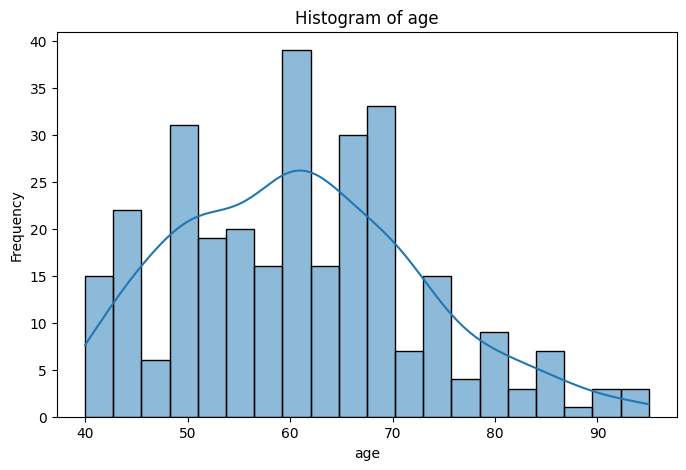

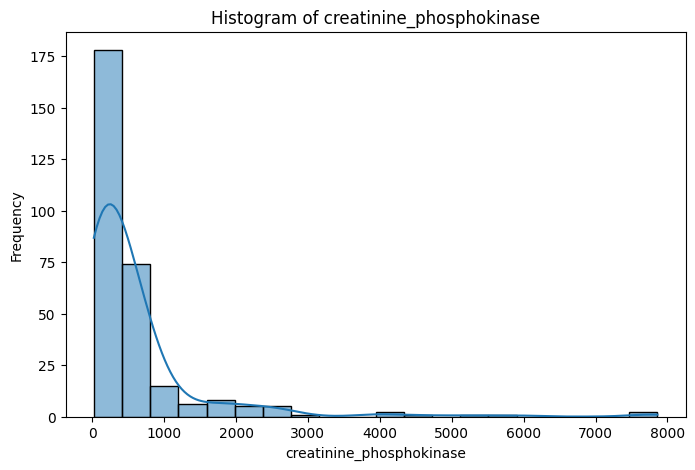

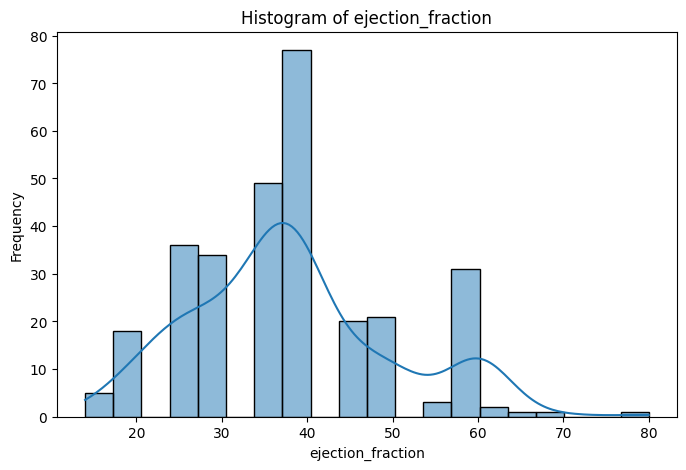

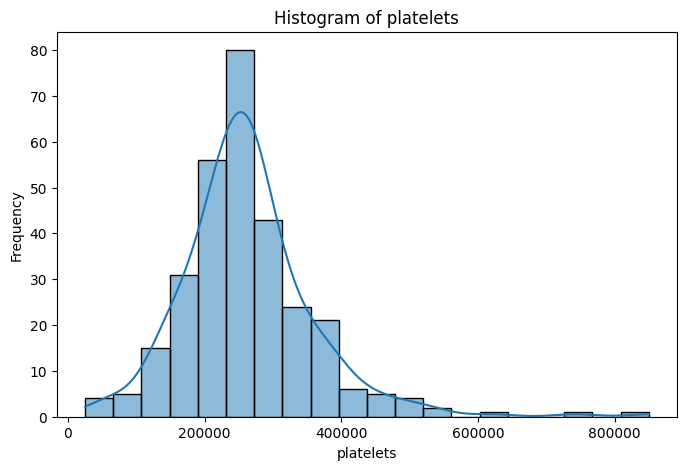

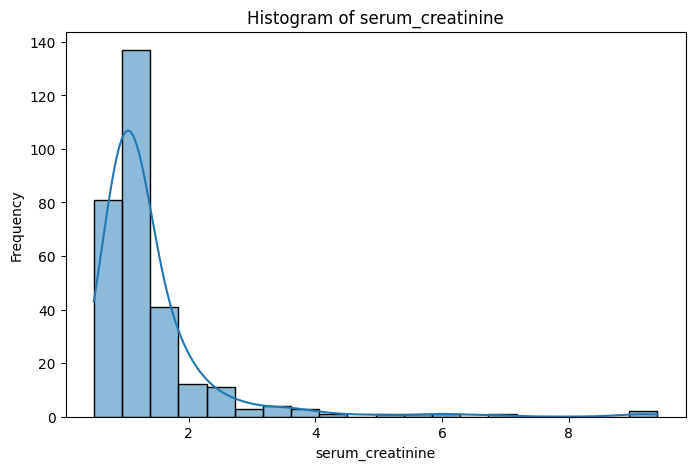

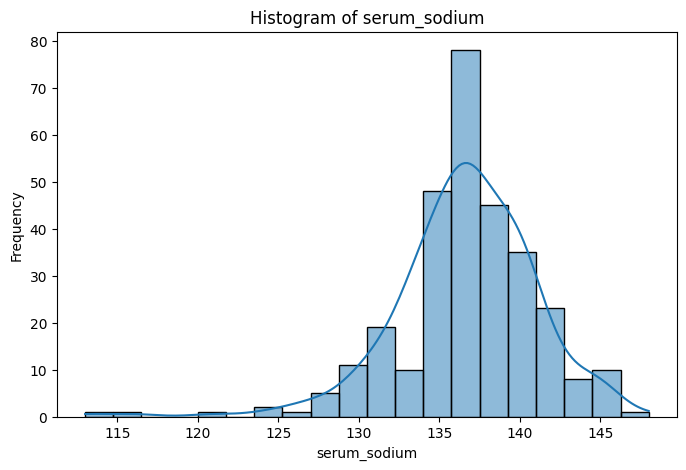

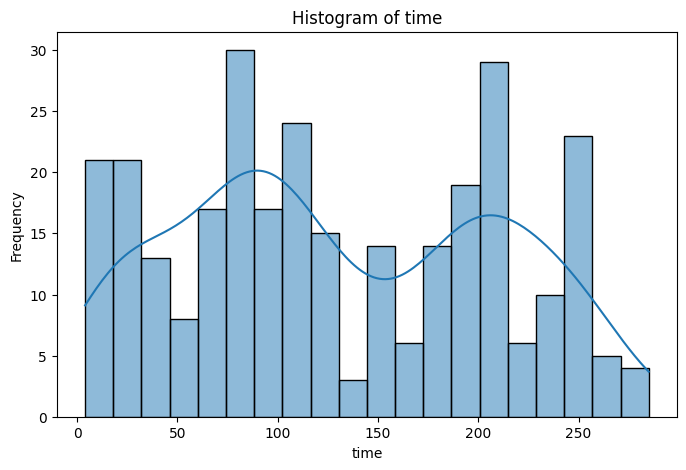

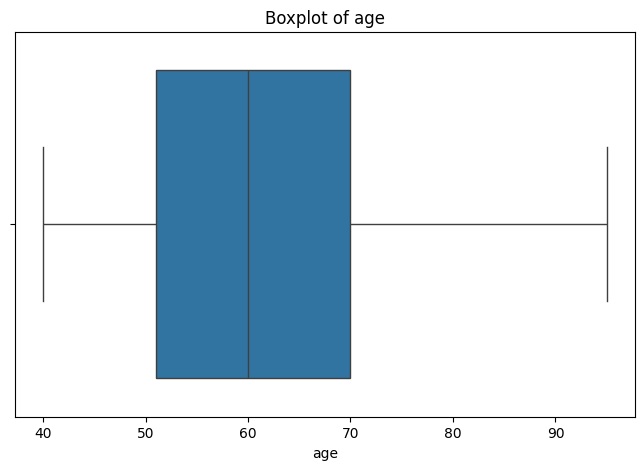

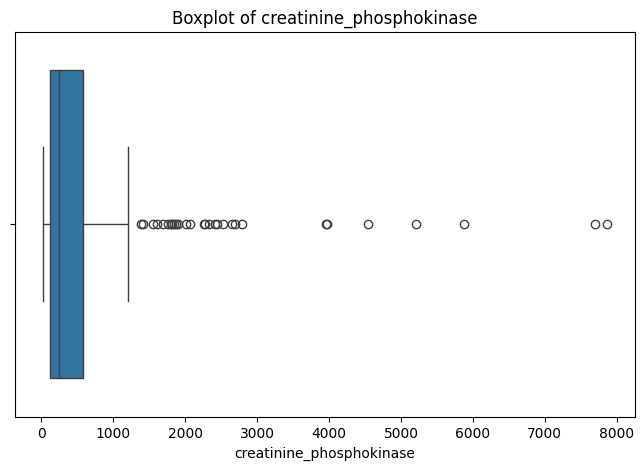

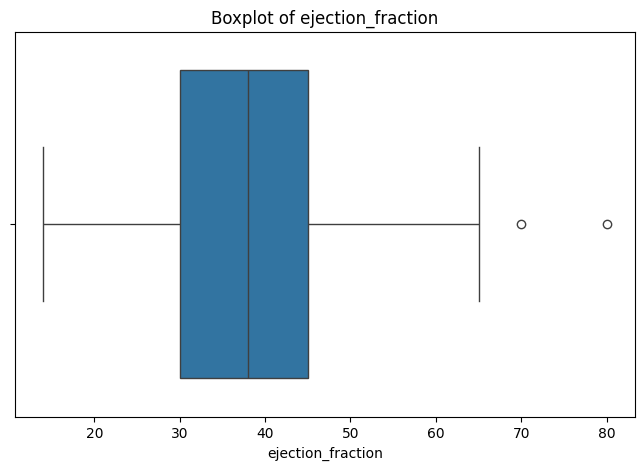

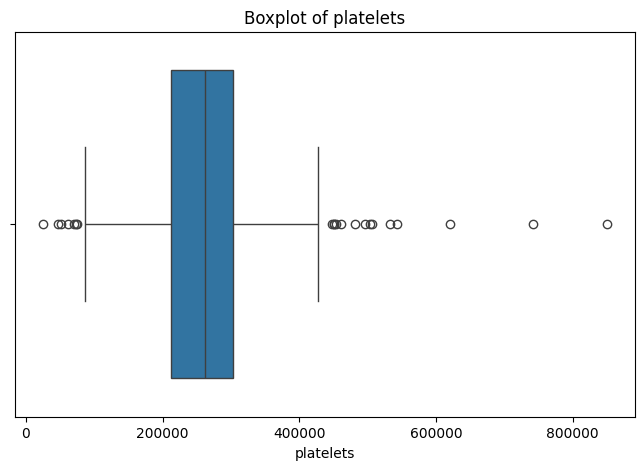

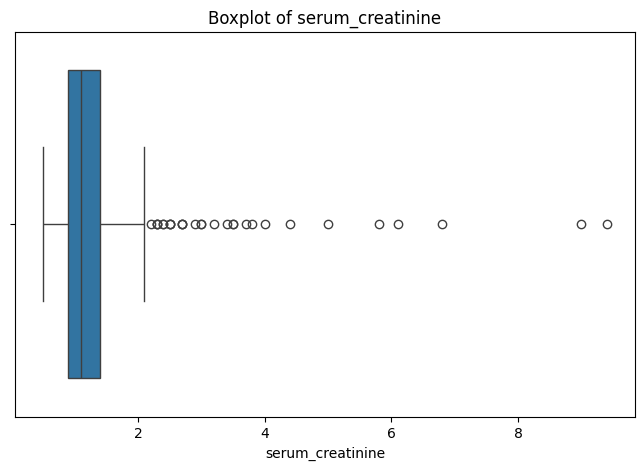

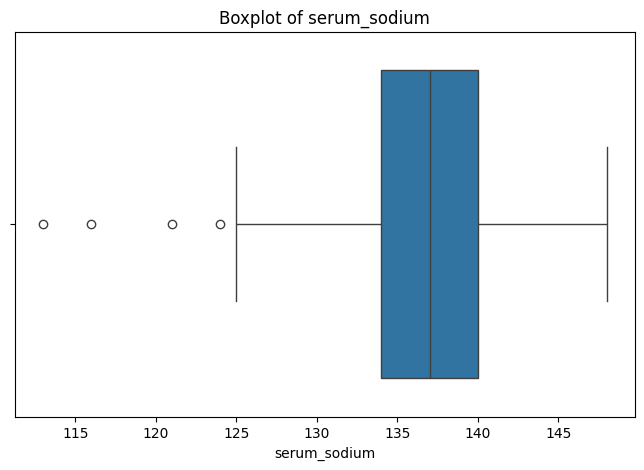

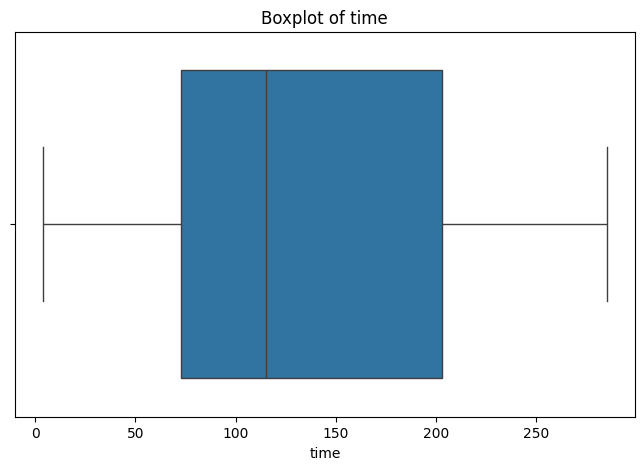

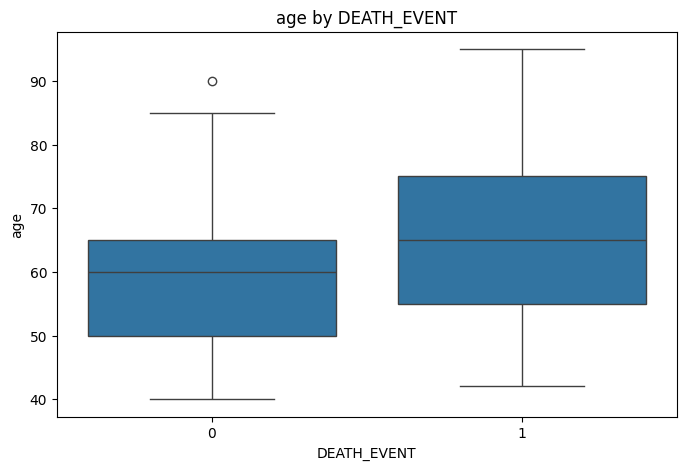

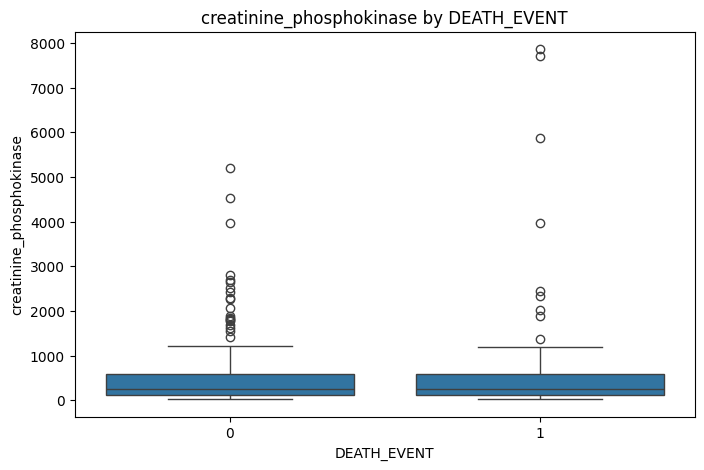

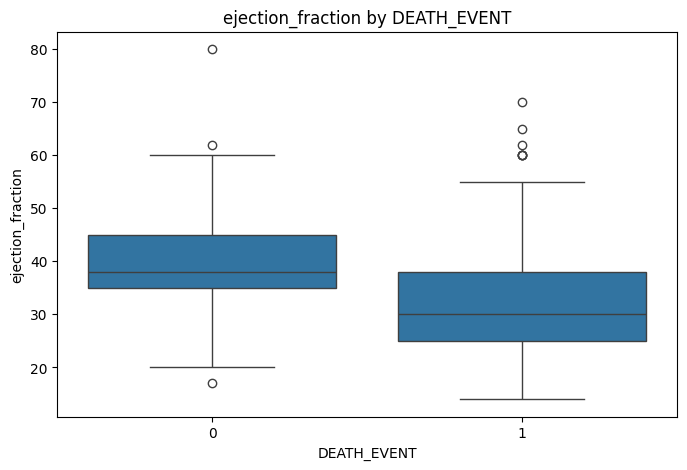

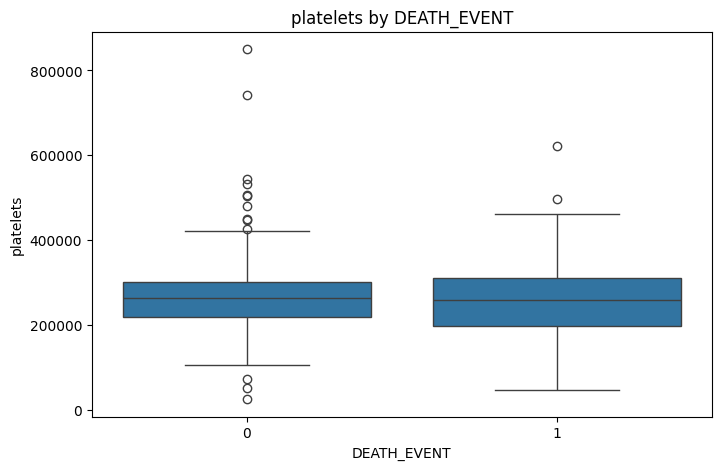

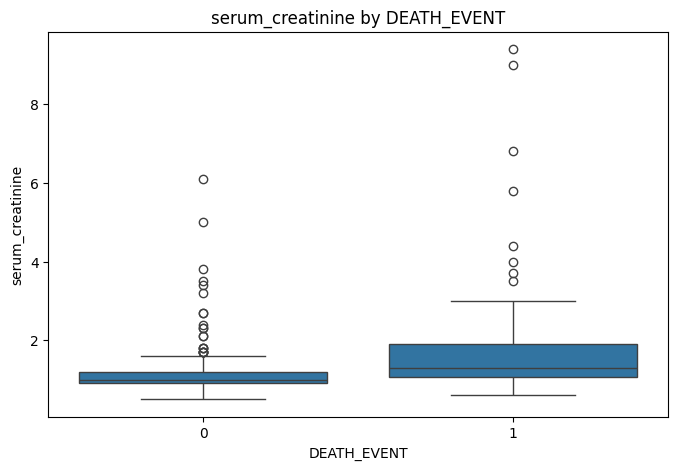

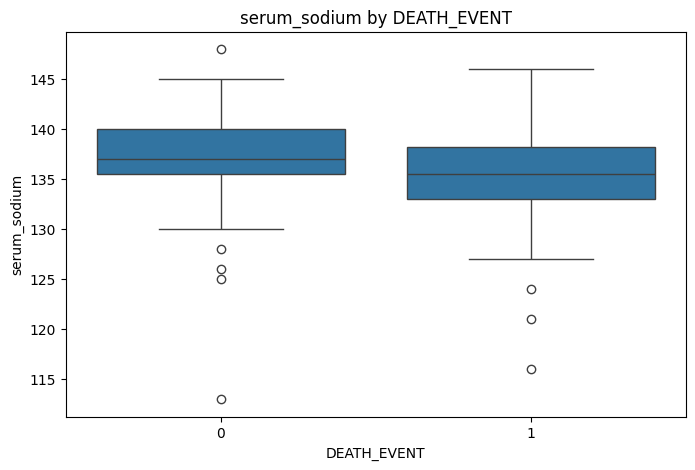

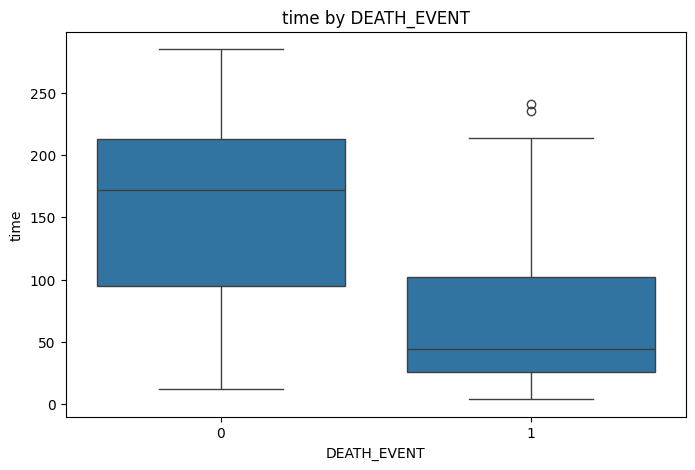

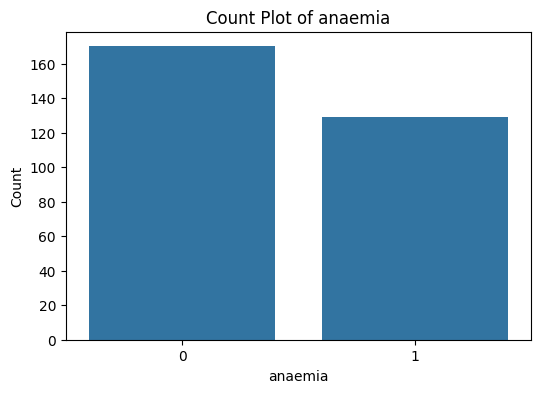

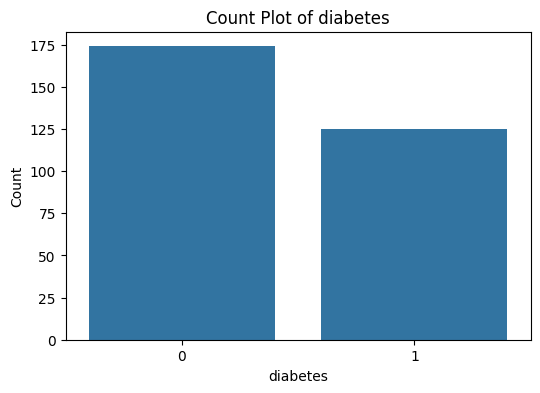

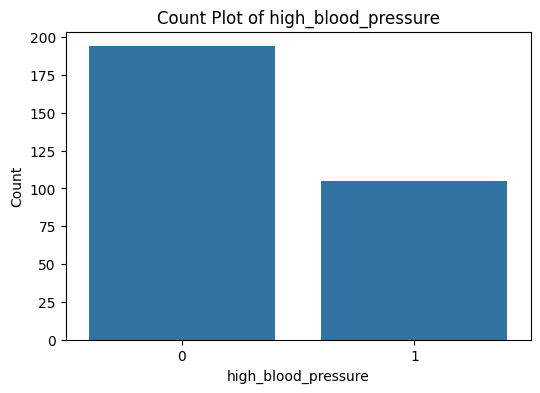

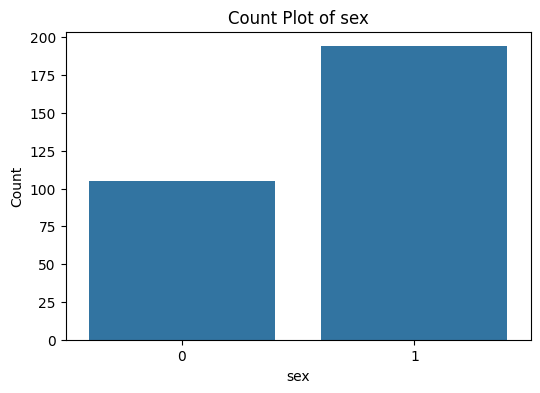

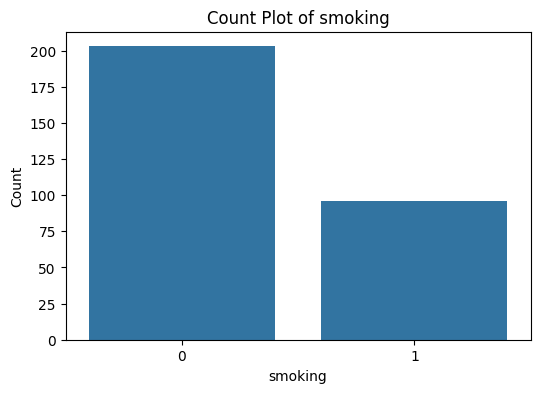

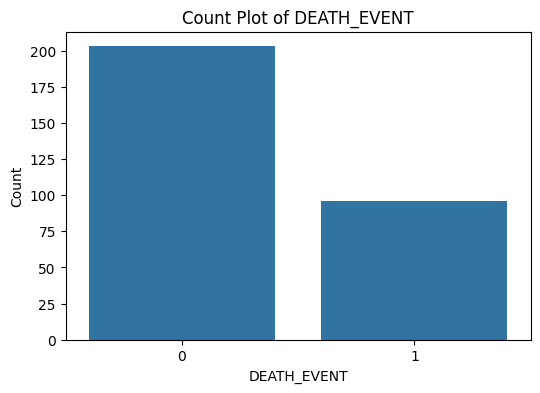

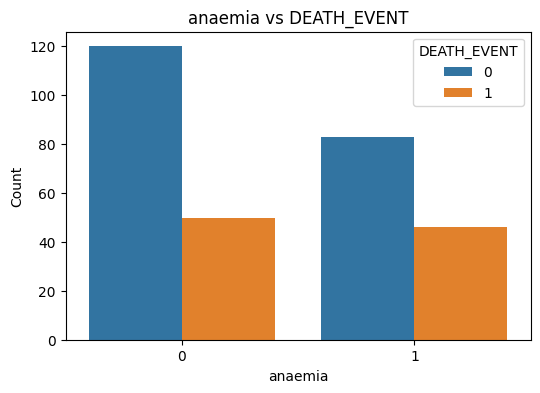

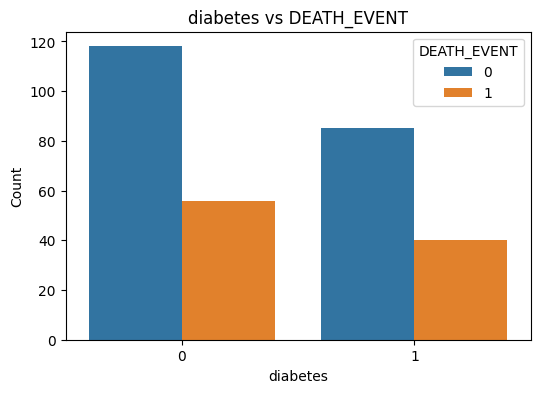

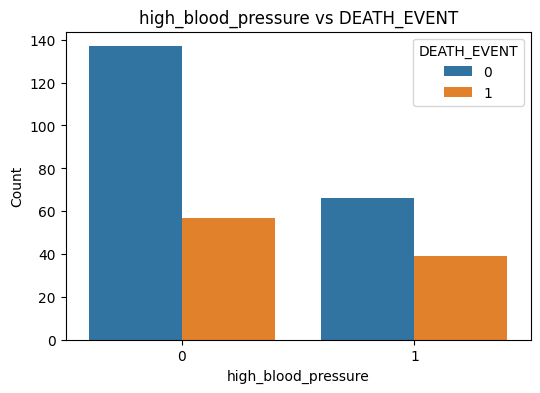

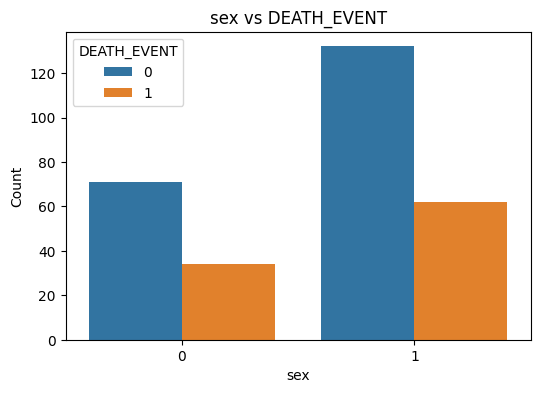

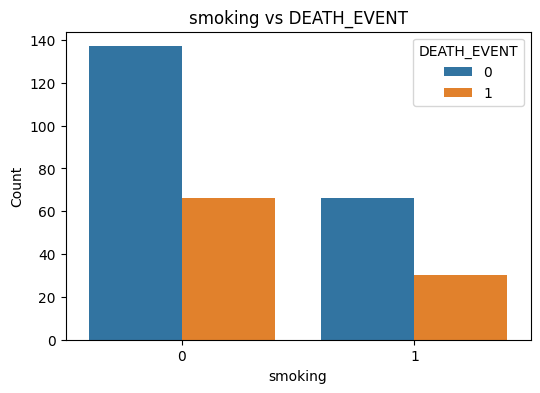

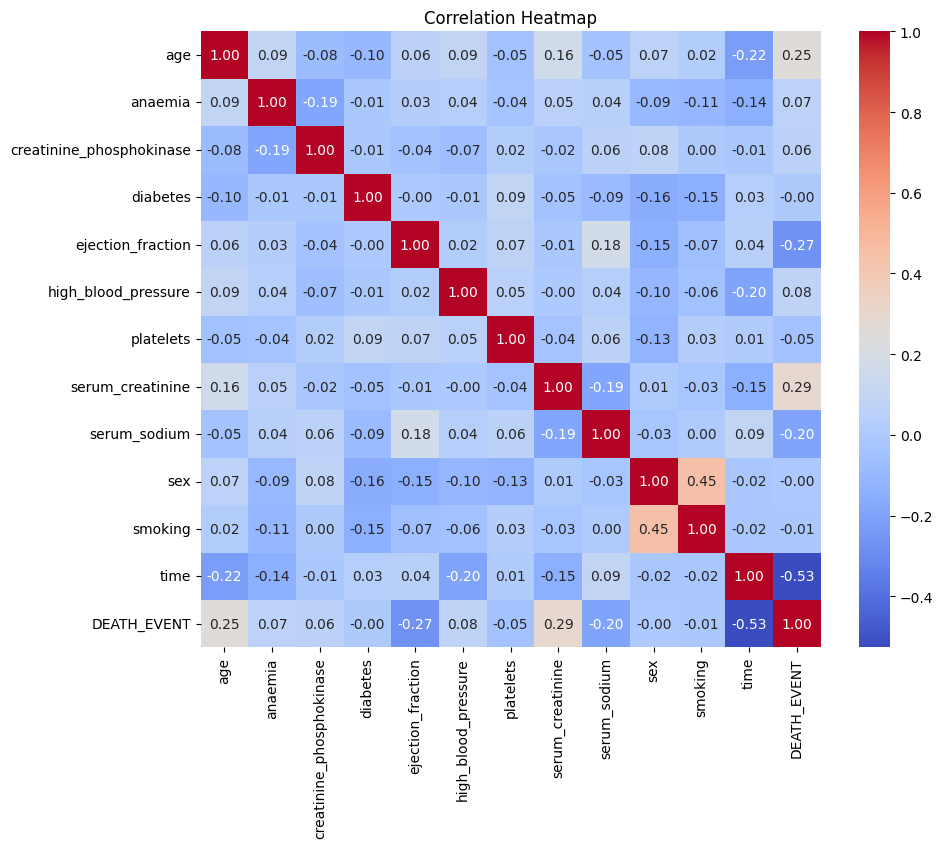

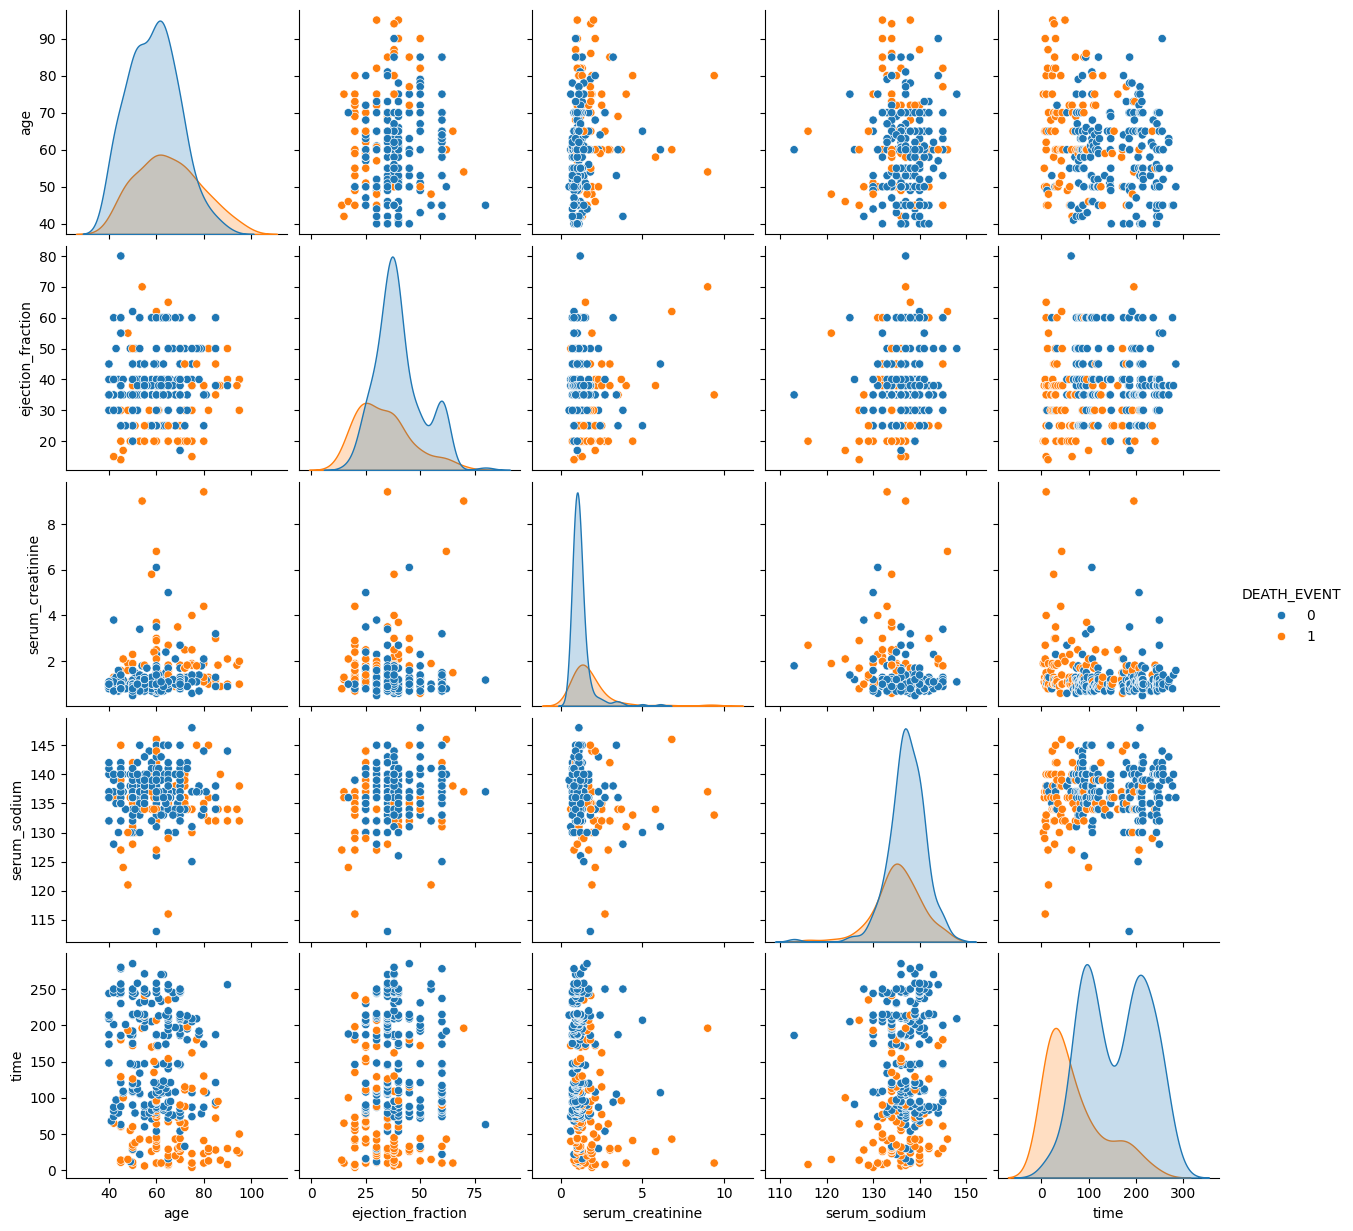


Outlier counts using IQR method:
age: 0 outliers
creatinine_phosphokinase: 29 outliers
ejection_fraction: 2 outliers
platelets: 21 outliers
serum_creatinine: 29 outliers
serum_sodium: 4 outliers
time: 0 outliers

Event rate by categorical variables:

anaemia vs DEATH_EVENT:
DEATH_EVENT    0   1  All
anaemia                  
0            120  50  170
1             83  46  129
All          203  96  299
Event rate (%):
anaemia
0    29.41
1    35.66
Name: DEATH_EVENT, dtype: float64

diabetes vs DEATH_EVENT:
DEATH_EVENT    0   1  All
diabetes                 
0            118  56  174
1             85  40  125
All          203  96  299
Event rate (%):
diabetes
0    32.18
1    32.00
Name: DEATH_EVENT, dtype: float64

high_blood_pressure vs DEATH_EVENT:
DEATH_EVENT            0   1  All
high_blood_pressure              
0                    137  57  194
1                     66  39  105
All                  203  96  299
Event rate (%):
high_blood_pressure
0    29.38
1    37.14
Name: DEATH_

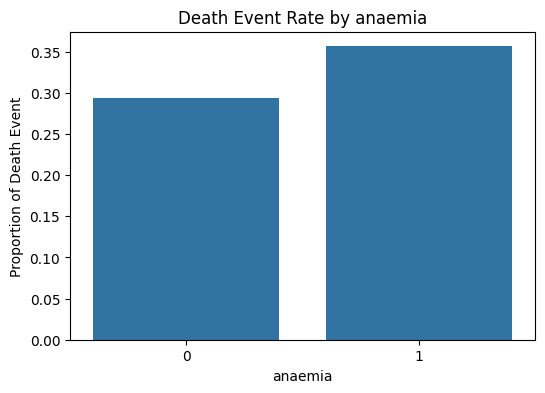

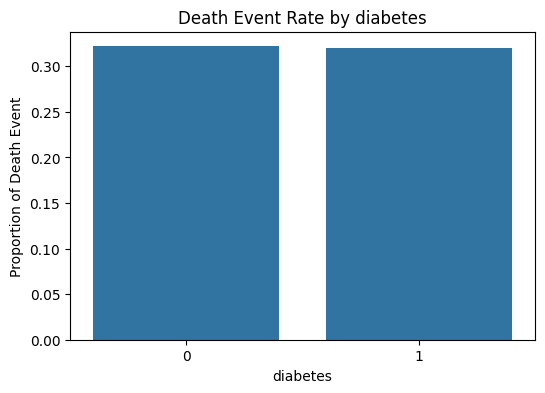

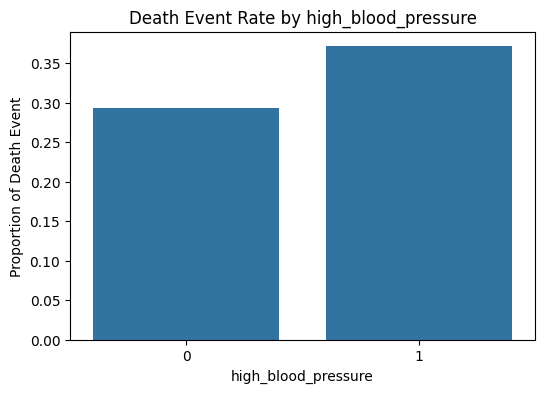

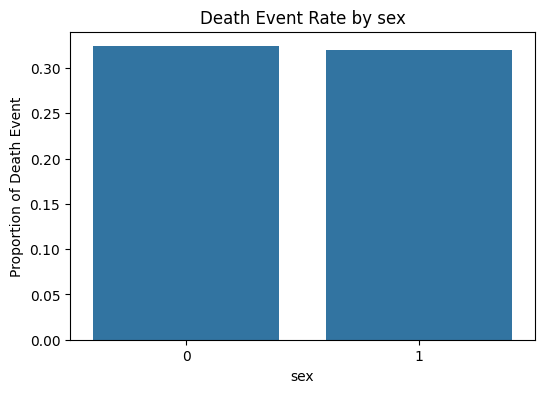

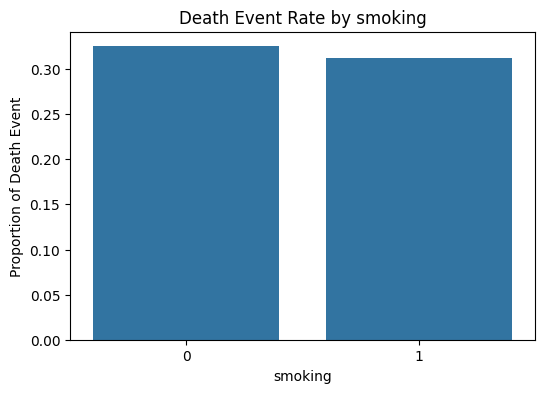

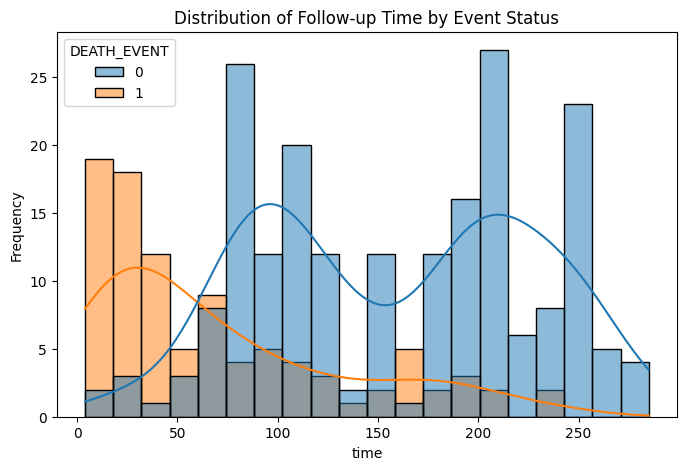

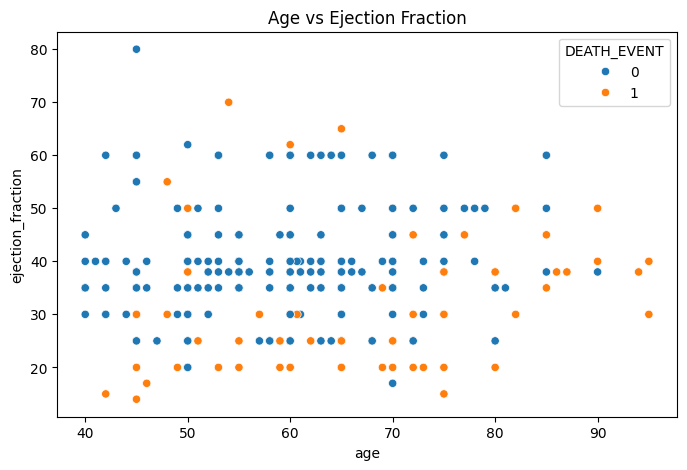

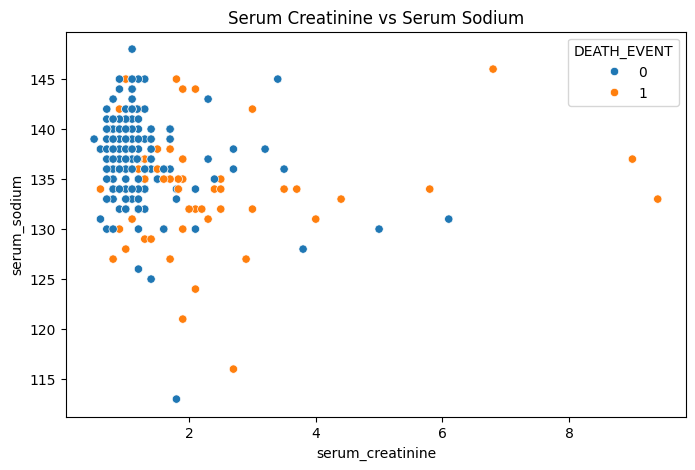


--- EDA SUMMARY ---
1. The dataset contains 299 rows and 13 columns.
2. No missing values:
3. DEATH_EVENT is the event indicator for survival analysis.
4. time is the follow-up duration variable.
5. Continuous predictors may need scaling/checking for skewness.
6. Variables like serum_creatinine and creatinine_phosphokinase may have outliers.
7. Group-wise comparison by DEATH_EVENT helps identify important predictors before Cox modeling.


In [8]:
# ================================
# HEART FAILURE DATASET - DETAILED EDA
# For Survival Analysis Project
# ================================


# Optional display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# -------------------------------
# 1. LOAD THE DATA
# -------------------------------
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# -------------------------------
# 2. BASIC DATA INSPECTION
# -------------------------------
print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic information:")
print(df.info())

# -------------------------------
# 3. CHECK MISSING VALUES
# -------------------------------
print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values in dataset:", df.isnull().sum().sum())

# -------------------------------
# 4. CHECK DUPLICATES
# -------------------------------
print("\nNumber of duplicate rows:", df.duplicated().sum())

# -------------------------------
# 5. DESCRIPTIVE STATISTICS
# -------------------------------
print("\nDescriptive statistics for numerical variables:")
print(df.describe())

# Median and IQR separately
print("\nMedian values:")
print(df.median(numeric_only=True))

print("\nInterquartile Range (IQR):")
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1
print(IQR)

# -------------------------------
# 6. IDENTIFY VARIABLE TYPES
# -------------------------------
continuous_vars = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

categorical_vars = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking",
    "DEATH_EVENT"
]

# -------------------------------
# 7. FREQUENCY TABLES FOR CATEGORICAL VARIABLES
# -------------------------------
print("\nFrequency tables for categorical variables:")
for col in categorical_vars:
    print(f"\nVariable: {col}")
    print(df[col].value_counts())
    print("Percentage:")
    print(round(df[col].value_counts(normalize=True) * 100, 2))

# -------------------------------
# 8. EVENT DISTRIBUTION
# -------------------------------
print("\nDistribution of event indicator (DEATH_EVENT):")
print(df["DEATH_EVENT"].value_counts())
print(round(df["DEATH_EVENT"].value_counts(normalize=True) * 100, 2))

print("\nSummary of follow-up time:")
print(df["time"].describe())

# -------------------------------
# 9. GROUP-WISE SUMMARY BY EVENT
# -------------------------------
print("\nMean values by DEATH_EVENT:")
print(df.groupby("DEATH_EVENT")[continuous_vars].mean())

print("\nMedian values by DEATH_EVENT:")
print(df.groupby("DEATH_EVENT")[continuous_vars].median())

# -------------------------------
# 10. HISTOGRAMS FOR CONTINUOUS VARIABLES
# -------------------------------
for col in continuous_vars:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# -------------------------------
# 11. BOXPLOTS FOR CONTINUOUS VARIABLES
# -------------------------------
for col in continuous_vars:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

# -------------------------------
# 12. BOXPLOTS OF CONTINUOUS VARIABLES BY EVENT STATUS
# -------------------------------
for col in continuous_vars:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x="DEATH_EVENT", y=col, data=df)
    plt.title(f"{col} by DEATH_EVENT")
    plt.xlabel("DEATH_EVENT")
    plt.ylabel(col)
    plt.show()

# -------------------------------
# 13. COUNT PLOTS FOR CATEGORICAL VARIABLES
# -------------------------------
for col in categorical_vars:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# -------------------------------
# 14. COUNT PLOTS OF CATEGORICAL VARIABLES BY EVENT
# -------------------------------
for col in categorical_vars:
    if col != "DEATH_EVENT":
        plt.figure(figsize=(6, 4))
        sns.countplot(x=col, hue="DEATH_EVENT", data=df)
        plt.title(f"{col} vs DEATH_EVENT")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.legend(title="DEATH_EVENT")
        plt.show()

# -------------------------------
# 15. CORRELATION MATRIX
# -------------------------------
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 16. PAIRPLOT FOR IMPORTANT CONTINUOUS VARIABLES
# -------------------------------
selected_vars = ["age", "ejection_fraction", "serum_creatinine", "serum_sodium", "time", "DEATH_EVENT"]
sns.pairplot(df[selected_vars], hue="DEATH_EVENT")
plt.show()

# -------------------------------
# 17. OUTLIER CHECK USING IQR METHOD
# -------------------------------
print("\nOutlier counts using IQR method:")
for col in continuous_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {outliers.shape[0]} outliers")

# -------------------------------
# 18. EVENT RATE BY CATEGORICAL VARIABLES
# -------------------------------
print("\nEvent rate by categorical variables:")
for col in categorical_vars:
    if col != "DEATH_EVENT":
        print(f"\n{col} vs DEATH_EVENT:")
        cross_tab = pd.crosstab(df[col], df["DEATH_EVENT"], margins=True)
        print(cross_tab)

        event_rate = df.groupby(col)["DEATH_EVENT"].mean() * 100
        print("Event rate (%):")
        print(round(event_rate, 2))

# -------------------------------
# 19. BARPLOT OF EVENT RATE FOR BINARY VARIABLES
# -------------------------------
binary_vars = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

for col in binary_vars:
    event_rate = df.groupby(col)["DEATH_EVENT"].mean().reset_index()
    
    plt.figure(figsize=(6, 4))
    sns.barplot(x=col, y="DEATH_EVENT", data=event_rate)
    plt.title(f"Death Event Rate by {col}")
    plt.ylabel("Proportion of Death Event")
    plt.show()

# -------------------------------
# 20. FOLLOW-UP TIME DISTRIBUTION BY EVENT STATUS
# -------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="time", hue="DEATH_EVENT", kde=True, bins=20)
plt.title("Distribution of Follow-up Time by Event Status")
plt.xlabel("time")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 21. SCATTER PLOTS FOR IMPORTANT RELATIONSHIPS
# -------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(x="age", y="ejection_fraction", hue="DEATH_EVENT", data=df)
plt.title("Age vs Ejection Fraction")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x="serum_creatinine", y="serum_sodium", hue="DEATH_EVENT", data=df)
plt.title("Serum Creatinine vs Serum Sodium")
plt.show()

# -------------------------------
# 22. SUMMARY INTERPRETATION PRINTS
# -------------------------------
print("\n--- EDA SUMMARY ---")
print("1. The dataset contains", df.shape[0], "rows and", df.shape[1], "columns.")
print("2. No missing values:" if df.isnull().sum().sum() == 0 else "2. There are missing values.")
print("3. DEATH_EVENT is the event indicator for survival analysis.")
print("4. time is the follow-up duration variable.")
print("5. Continuous predictors may need scaling/checking for skewness.")
print("6. Variables like serum_creatinine and creatinine_phosphokinase may have outliers.")
print("7. Group-wise comparison by DEATH_EVENT helps identify important predictors before Cox modeling.")

<Axes: ylabel='Frequency'>

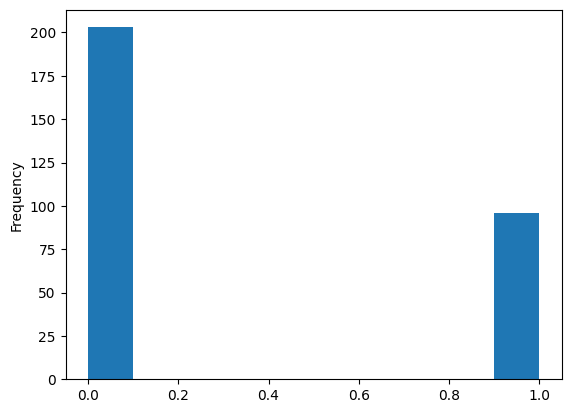

In [9]:
import seaborn as sns
df['DEATH_EVENT'].plot(kind='hist')

Dataset shape: (299, 13)
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  smoking  time  DEATH_EVENT
0  75.0        0                       582         0                 20                    1  265000.00               1.9           130    1        0     4            1
1  55.0        0                      7861         0                 38                    0  263358.03               1.1           136    1        0     6            1
2  65.0        0                       146         0                 20                    0  162000.00               1.3           129    1        1     7            1
3  50.0        1                       111         0                 20                    0  210000.00               1.9           137    1        0     7            1
4  65.0        1                       160         1                 20                    0  327000.00               2.7         

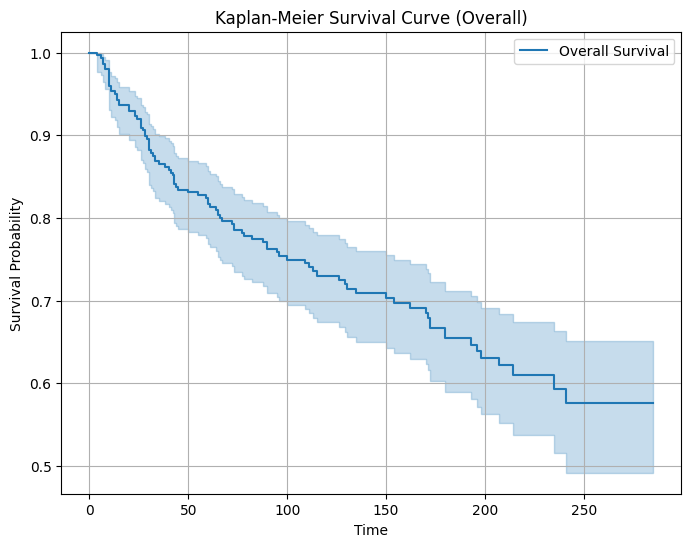


Analysis for variable: anaemia


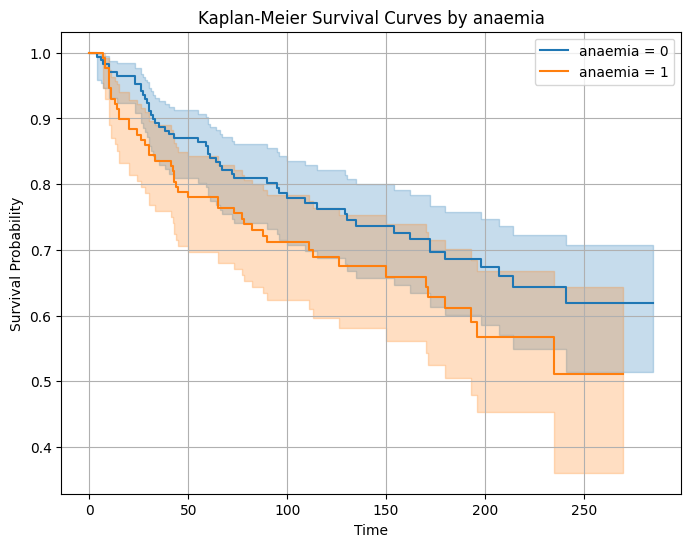


Log-rank test for anaemia
Test statistic: 2.7265
p-value: 0.098698
Interpretation: No statistically significant difference in survival curves between the two groups.


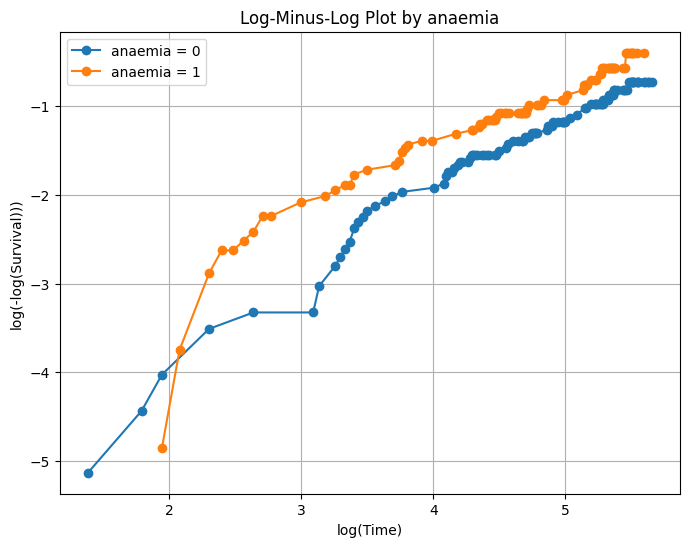


PH visual check for anaemia:
If the two log-minus-log curves are roughly parallel and do not cross much,
the proportional hazards assumption may be reasonable for this variable.

Analysis for variable: diabetes


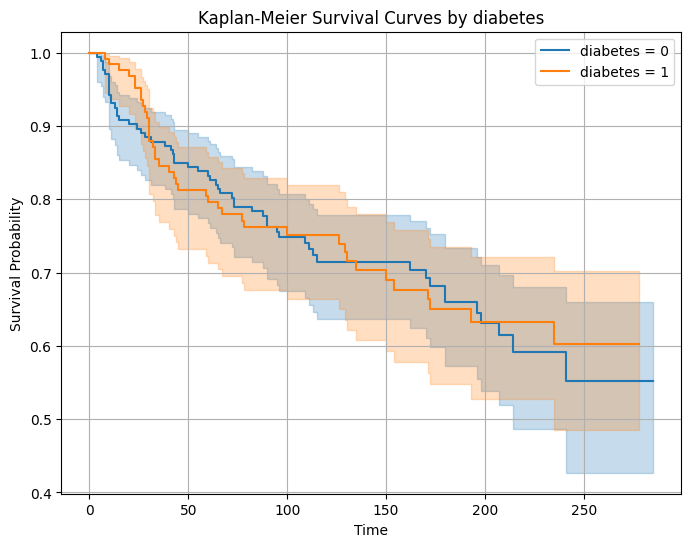


Log-rank test for diabetes
Test statistic: 0.0405
p-value: 0.840452
Interpretation: No statistically significant difference in survival curves between the two groups.


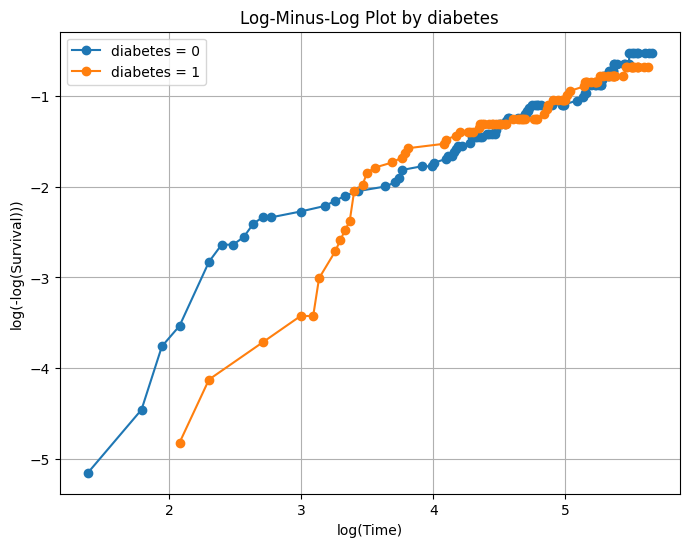


PH visual check for diabetes:
If the two log-minus-log curves are roughly parallel and do not cross much,
the proportional hazards assumption may be reasonable for this variable.

Analysis for variable: high_blood_pressure


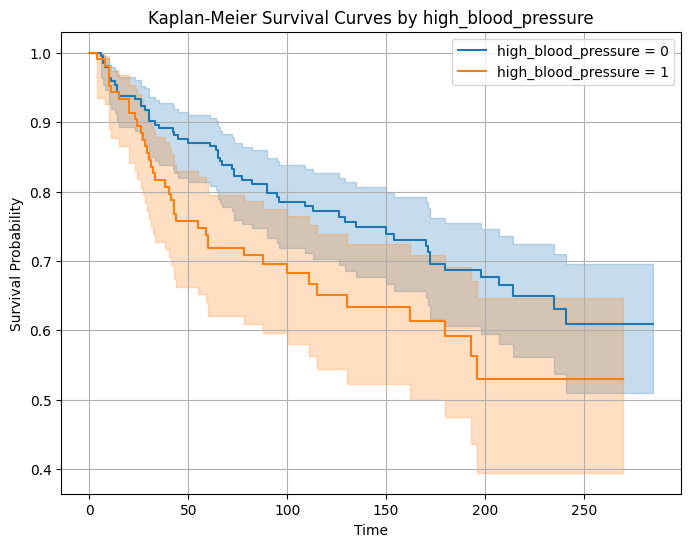


Log-rank test for high_blood_pressure
Test statistic: 4.4062
p-value: 0.035808
Interpretation: Survival curves differ significantly between the two groups.


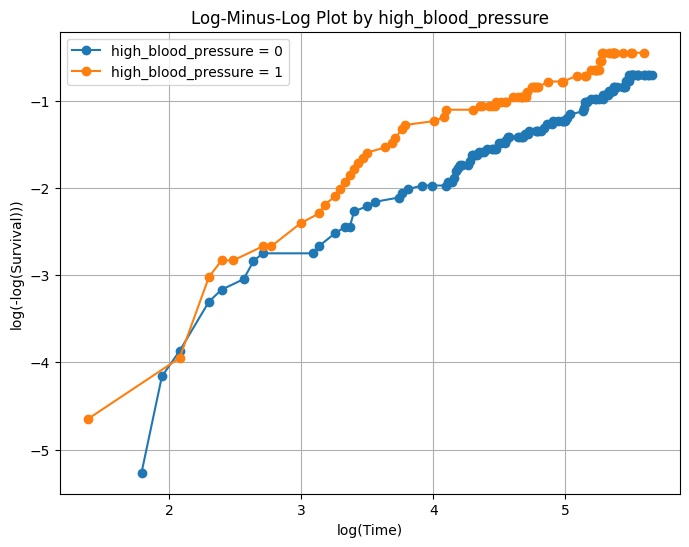


PH visual check for high_blood_pressure:
If the two log-minus-log curves are roughly parallel and do not cross much,
the proportional hazards assumption may be reasonable for this variable.

Analysis for variable: sex


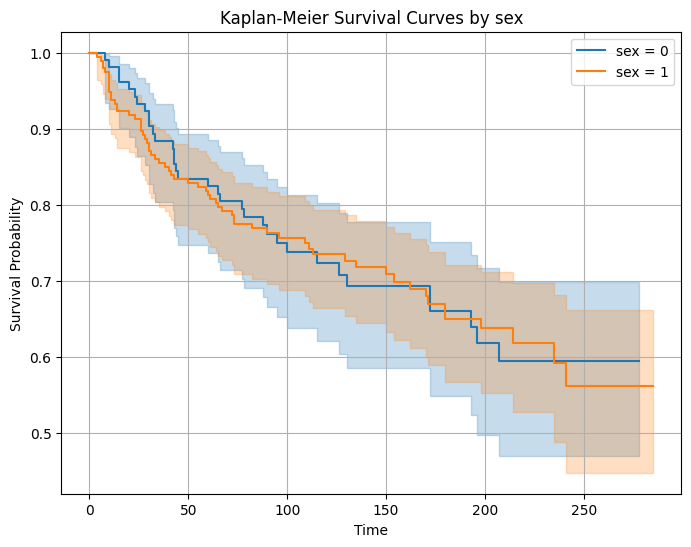


Log-rank test for sex
Test statistic: 0.004
p-value: 0.949752
Interpretation: No statistically significant difference in survival curves between the two groups.


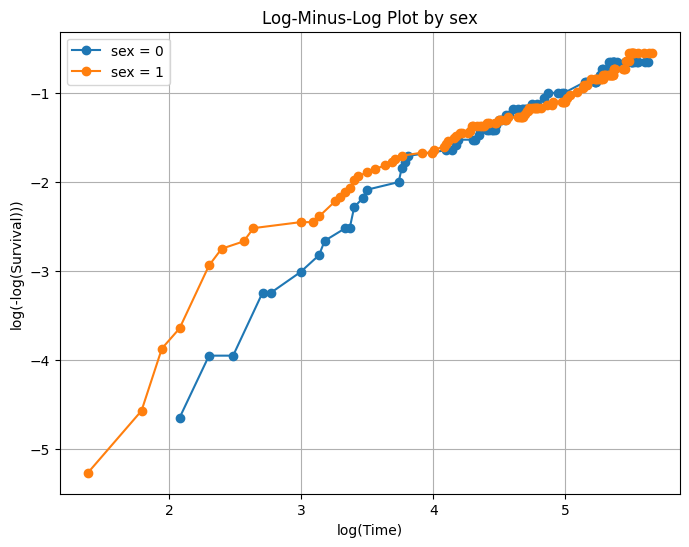


PH visual check for sex:
If the two log-minus-log curves are roughly parallel and do not cross much,
the proportional hazards assumption may be reasonable for this variable.

Analysis for variable: smoking


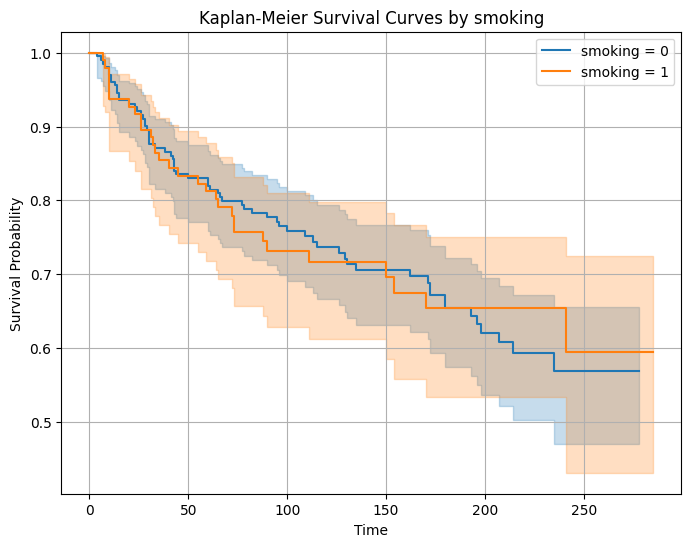


Log-rank test for smoking
Test statistic: 0.002
p-value: 0.96396
Interpretation: No statistically significant difference in survival curves between the two groups.


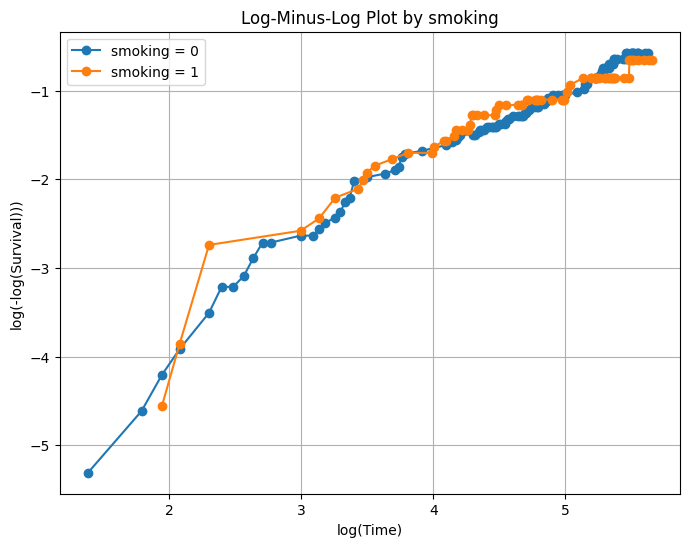


PH visual check for smoking:
If the two log-minus-log curves are roughly parallel and do not cross much,
the proportional hazards assumption may be reasonable for this variable.


In [10]:
# ============================================
# SURVIVAL ANALYSIS: KAPLAN-MEIER + LOG-RANK
# + LOG-MINUS-LOG PLOTS FOR PH CHECK
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# -------------------------------
# 1. Load dataset
# -------------------------------
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# Survival variables
time_col = "time"
event_col = "DEATH_EVENT"

print("Dataset shape:", df.shape)
print(df.head())

# -------------------------------
# 2. Basic overall Kaplan-Meier curve
# -------------------------------
kmf = KaplanMeierFitter()

plt.figure(figsize=(8, 6))
kmf.fit(durations=df[time_col], event_observed=df[event_col], label="Overall Survival")
kmf.plot_survival_function(ci_show=True)
plt.title("Kaplan-Meier Survival Curve (Overall)")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()


# ----------------------------------------------------
# 3. Function to plot KM curve by binary group
# ----------------------------------------------------
def plot_km_by_group(data, group_col, time_col="time", event_col="DEATH_EVENT"):
    kmf0 = KaplanMeierFitter()
    kmf1 = KaplanMeierFitter()

    group0 = data[data[group_col] == 0]
    group1 = data[data[group_col] == 1]

    plt.figure(figsize=(8, 6))

    kmf0.fit(group0[time_col], event_observed=group0[event_col], label=f"{group_col} = 0")
    kmf0.plot_survival_function(ci_show=True)

    kmf1.fit(group1[time_col], event_observed=group1[event_col], label=f"{group_col} = 1")
    kmf1.plot_survival_function(ci_show=True)

    plt.title(f"Kaplan-Meier Survival Curves by {group_col}")
    plt.xlabel("Time")
    plt.ylabel("Survival Probability")
    plt.grid(True)
    plt.savefig(f"survival_plots/{group_col}_km.png", dpi=300, bbox_inches="tight")
    plt.show()


# ----------------------------------------------------
# 4. Function to perform log-rank test
# ----------------------------------------------------
def perform_logrank_test(data, group_col, time_col="time", event_col="DEATH_EVENT"):
    group0 = data[data[group_col] == 0]
    group1 = data[data[group_col] == 1]

    results = logrank_test(
        durations_A=group0[time_col],
        durations_B=group1[time_col],
        event_observed_A=group0[event_col],
        event_observed_B=group1[event_col]
    )

    print(f"\nLog-rank test for {group_col}")
    print("Test statistic:", round(results.test_statistic, 4))
    print("p-value:", round(results.p_value, 6))

    if results.p_value < 0.05:
        print("Interpretation: Survival curves differ significantly between the two groups.")
    else:
        print("Interpretation: No statistically significant difference in survival curves between the two groups.")


# ----------------------------------------------------
# 5. Function for log-minus-log plot (PH visual check)
# ----------------------------------------------------
def plot_log_minus_log(data, group_col, time_col="time", event_col="DEATH_EVENT"):
    """
    Plot log(-log(S(t))) vs log(time)
    Used as a visual check for proportional hazards assumption.
    Roughly parallel curves support PH assumption.
    """

    kmf0 = KaplanMeierFitter()
    kmf1 = KaplanMeierFitter()

    group0 = data[data[group_col] == 0]
    group1 = data[data[group_col] == 1]

    kmf0.fit(group0[time_col], event_observed=group0[event_col], label=f"{group_col} = 0")
    kmf1.fit(group1[time_col], event_observed=group1[event_col], label=f"{group_col} = 1")

    # Survival functions
    sf0 = kmf0.survival_function_.copy()
    sf1 = kmf1.survival_function_.copy()

    # Remove invalid values for transformation
    sf0 = sf0[(sf0.index > 0) & (sf0.iloc[:, 0] > 0) & (sf0.iloc[:, 0] < 1)]
    sf1 = sf1[(sf1.index > 0) & (sf1.iloc[:, 0] > 0) & (sf1.iloc[:, 0] < 1)]

    # Transformations
    x0 = np.log(sf0.index)
    y0 = np.log(-np.log(sf0.iloc[:, 0]))

    x1 = np.log(sf1.index)
    y1 = np.log(-np.log(sf1.iloc[:, 0]))

    plt.figure(figsize=(8, 6))
    plt.plot(x0, y0, marker='o', linestyle='-', label=f"{group_col} = 0")
    plt.plot(x1, y1, marker='o', linestyle='-', label=f"{group_col} = 1")

    plt.title(f"Log-Minus-Log Plot by {group_col}")
    plt.xlabel("log(Time)")
    plt.ylabel("log(-log(Survival)))")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"survival_plots/{group_col}_logminuslog.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"\nPH visual check for {group_col}:")
    print("If the two log-minus-log curves are roughly parallel and do not cross much,")
    print("the proportional hazards assumption may be reasonable for this variable.")


# ----------------------------------------------------
# 6. Apply to all binary predictors
# ----------------------------------------------------
binary_vars = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

for var in binary_vars:
    print("\n" + "="*60)
    print(f"Analysis for variable: {var}")
    print("="*60)

    # Kaplan-Meier curves
    plot_km_by_group(df, var, time_col, event_col)

    # Log-rank test
    perform_logrank_test(df, var, time_col, event_col)

    # Log-minus-log plot for PH assumption
    plot_log_minus_log(df, var, time_col, event_col)

age_group created using median = 60.0
ejection_fraction_group created using median = 38.0
serum_creatinine_group created using median = 1.1
serum_sodium_group created using median = 137.0

Analysis for variable: age_group


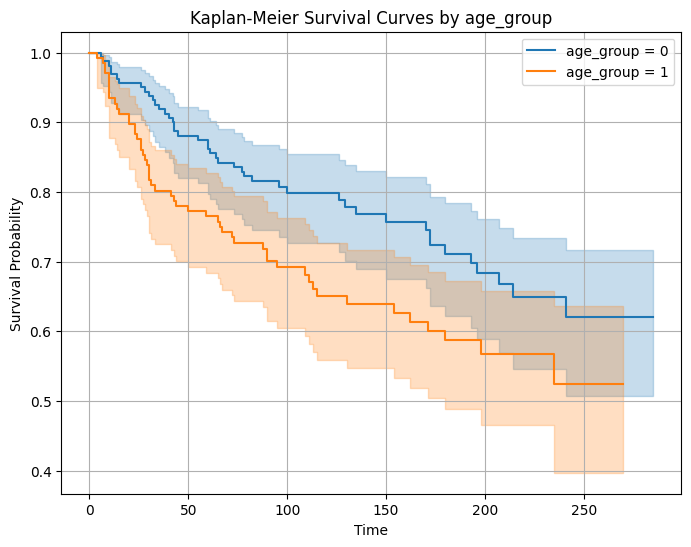


Log-rank test for age_group
Test statistic: 4.9518
p-value: 0.026064
Interpretation: Survival curves differ significantly between the two groups.


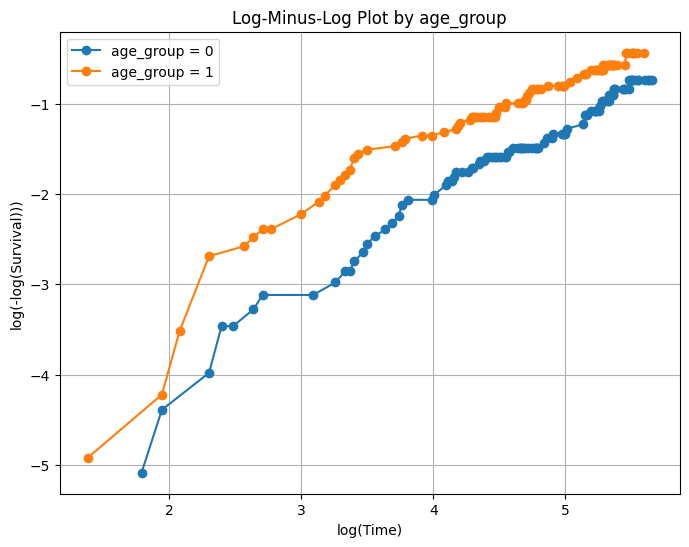


PH visual check for age_group:
If the two log-minus-log curves are roughly parallel and do not cross much,
the proportional hazards assumption may be reasonable for this variable.

Analysis for variable: ejection_fraction_group


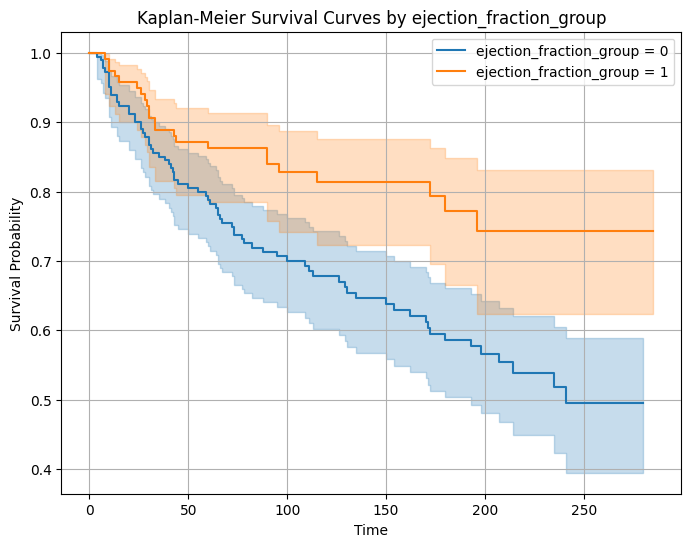


Log-rank test for ejection_fraction_group
Test statistic: 9.4696
p-value: 0.002089
Interpretation: Survival curves differ significantly between the two groups.


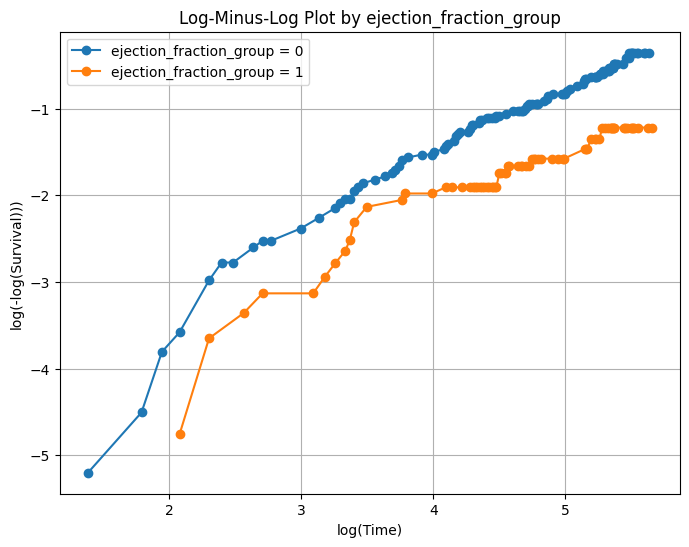


PH visual check for ejection_fraction_group:
If the two log-minus-log curves are roughly parallel and do not cross much,
the proportional hazards assumption may be reasonable for this variable.

Analysis for variable: serum_creatinine_group


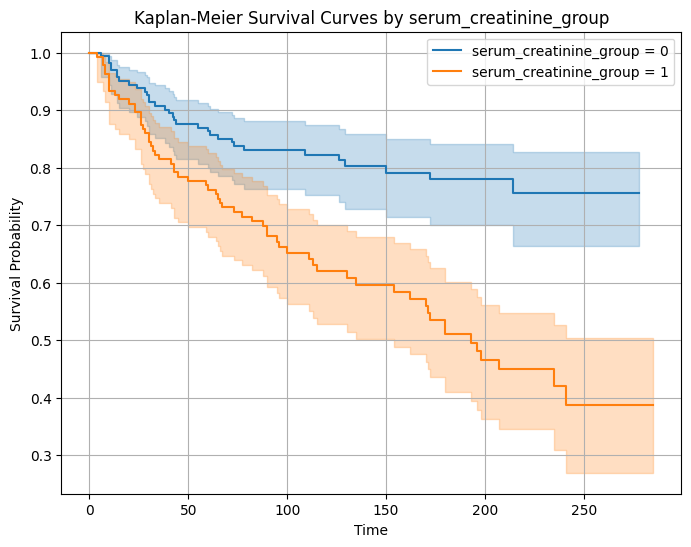


Log-rank test for serum_creatinine_group
Test statistic: 21.1904
p-value: 4e-06
Interpretation: Survival curves differ significantly between the two groups.


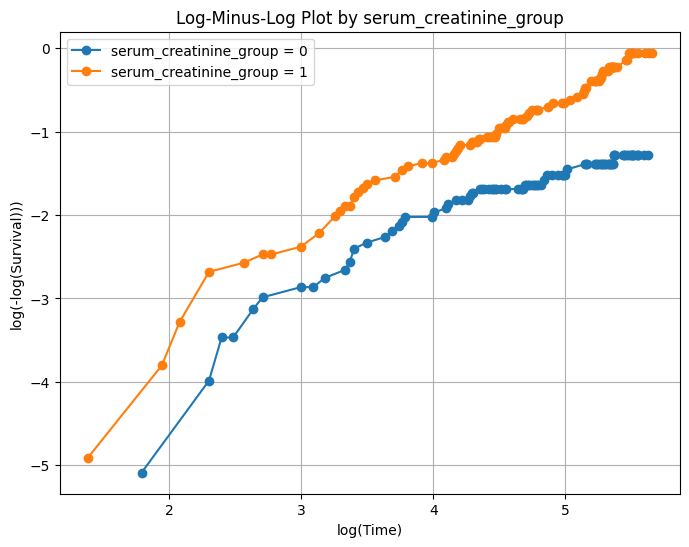


PH visual check for serum_creatinine_group:
If the two log-minus-log curves are roughly parallel and do not cross much,
the proportional hazards assumption may be reasonable for this variable.

Analysis for variable: serum_sodium_group


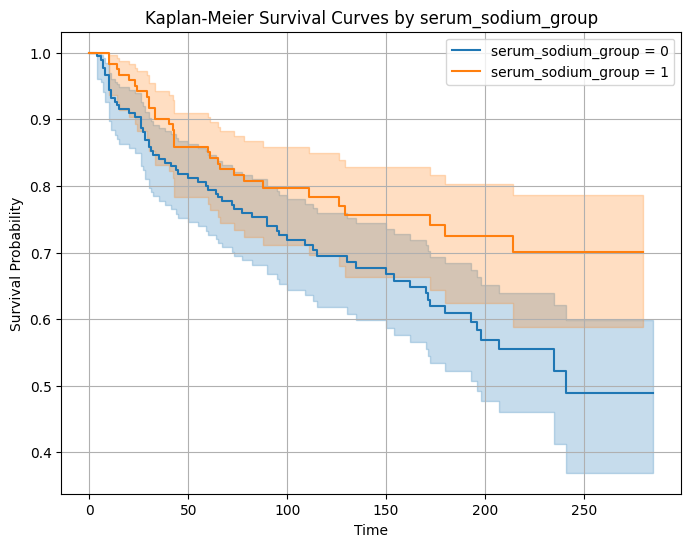


Log-rank test for serum_sodium_group
Test statistic: 4.8879
p-value: 0.027046
Interpretation: Survival curves differ significantly between the two groups.


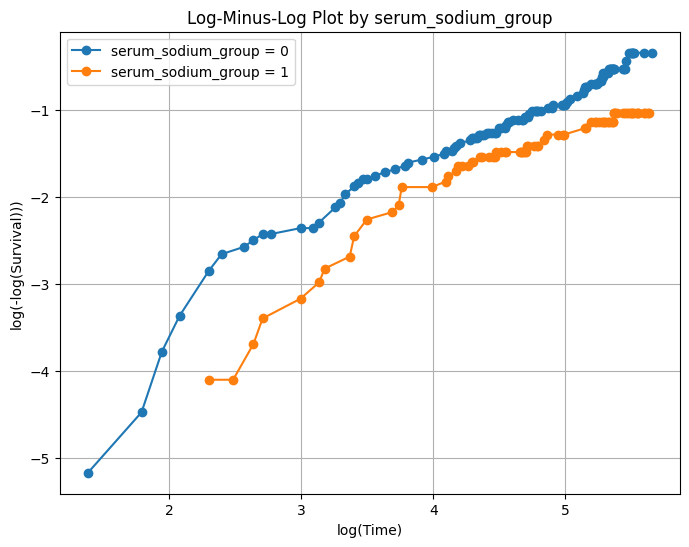


PH visual check for serum_sodium_group:
If the two log-minus-log curves are roughly parallel and do not cross much,
the proportional hazards assumption may be reasonable for this variable.


In [11]:
# ----------------------------------------------------
# 7. Create median-based groups for continuous variables
# ----------------------------------------------------
continuous_vars = ["age", "ejection_fraction", "serum_creatinine", "serum_sodium"]

for var in continuous_vars:
    median_value = df[var].median()
    new_col = var + "_group"
    df[new_col] = np.where(df[var] <= median_value, 0, 1)

    print(f"{new_col} created using median = {median_value}")


# ----------------------------------------------------
# 8. Run KM + log-rank + log-minus-log for grouped continuous vars
# ----------------------------------------------------
grouped_vars = [v + "_group" for v in continuous_vars]

for var in grouped_vars:
    print("\n" + "="*60)
    print(f"Analysis for variable: {var}")
    print("="*60)

    plot_km_by_group(df, var, time_col, event_col)
    perform_logrank_test(df, var, time_col, event_col)
    plot_log_minus_log(df, var, time_col, event_col)

Shape of Cox dataset: (299, 13)
   time  DEATH_EVENT   age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  smoking
0     4            1  75.0        0                       582         0                 20                    1  265000.00               1.9           130    1        0
1     6            1  55.0        0                      7861         0                 38                    0  263358.03               1.1           136    1        0
2     7            1  65.0        0                       146         0                 20                    0  162000.00               1.3           129    1        1
3     7            1  50.0        1                       111         0                 20                    0  210000.00               1.9           137    1        0
4     8            1  65.0        1                       160         1                 20                    0  327000.00 

<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -468.23
         time fit was run = 2026-04-14 04:38:14 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
age                       0.05      1.05      0.01            0.03            0.06                1.03                1.07
anaemia                   0.46      1.58      0.22            0.04            0.89                1.04                2.42
creatinine_phosphokinase  0.00      1.00      0.00            0.00            0.00                1.00                1.00
diabetes                  0.14      1.15      0.22           -0.30            0.58                0.74                1.78
ejection_fraction        -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
high_blood_pressure       0.48      1.61      0.22            0.05            0.90                1.05                2.46
platelets                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
serum_creatinine          0.32      1.38      0.07            0.18            0.46                1.20                1.58
serum_sodium             -0.04      0.96      0.02           -0.09            0.00                0.91                1.00
sex                      -0.24      0.79      0.25           -0.73            0.26                0.48                1.29
smoking                   0.13      1.14      0.25           -0.36            0.62                0.70                1.86

                          cmp to     z      p  -log2(p)
covariate                                              
age                         0.00  4.98 <0.005     20.56
anaemia                     0.00  2.12   0.03      4.89
creatinine_phosphokinase    0.00  2.23   0.03      5.26
diabetes                    0.00  0.63   0.53      0.91
ejection_fraction           0.00 -4.67 <0.005     18.35
high_blood_pressure         0.00  2.20   0.03      5.17
platelets                   0.00 -0.41   0.68      0.56
serum_creatinine            0.00  4.58 <0.005     17.68
serum_sodium                0.00 -1.90   0.06      4.12
sex                         0.00 -0.94   0.35      1.53
smoking                     0.00  0.51   0.61      0.72
---
Concordance = 0.74
Partial AIC = 958.46
log-likelihood ratio test = 81.95 on 11 df
-log2(p) of ll-ratio test = 40.56


===== HAZARD RATIOS =====
                                  coef  exp(coef)  se(coef)             p        HR  HR_lower_95  HR_upper_95
covariate                                                                                                    
age                       4.640818e-02   1.047502  0.009324  6.448780e-07  1.047502     1.028533     1.066821
anaemia                   4.601351e-01   1.584288  0.216837  3.383470e-02  1.584288     1.035768     2.423292
creatinine_phosphokinase  2.207372e-04   1.000221  0.000099  2.604761e-02  1.000221     1.000026     1.000415
diabetes                  1.398843e-01   1.150141  0.223147  5.307444e-01  1.150141     0.742690     1.781124
ejection_fraction        -4.894160e-02   0.952237  0.010476  2.984594e-06  0.952237     0.932885     0.971990
high_blood_pressure       4.757492e-01   1.609219  0.216197  2.776890e-02  1.609219     1.053387     2.458343
platelets                -4.635209e-07   1.000000  0.000001  6.806373e-01  1.000000     0.999

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
         test_name = proportional_hazard_test

---
                               test_statistic    p  -log2(p)
age                      km              0.11 0.74      0.43
                         rank            0.03 0.86      0.21
anaemia                  km              0.00 1.00      0.00
                         rank            0.01 0.93      0.11
creatinine_phosphokinase km              1.13 0.29      1.79
                         rank            1.11 0.29      1.77
diabetes                 km              0.04 0.84      0.25
                         rank            0.00 0.99      0.02
ejection_fraction        km              5.85 0.02      6.00
                         rank            6.21 0.01      6.30
high_blood_pressure      km              0.11 0.74      0.44
                         rank            0.11 0.74      0.44
platelets                km              0.04 0.85      0.24
                         rank            0.11 0.74      0.44
serum_creatinine         km              3.22 0.07      3.78
                         rank            3.48 0.06      4.00
serum_sodium             km              1.10 0.29      1.76
                         rank            1.73 0.19      2.41
sex                      km              0.09 0.76      0.39
                         rank            0.26 0.61      0.71
smoking                  km              0.58 0.45      1.16
                         rank            0.33 0.57      0.82



1. Variable 'ejection_fraction' failed the non-proportional test: p-value is 0.0127.

   Advice 1: the functional form of the variable 'ejection_fraction' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'ejection_fraction' using pd.cut, and then specify it in
`strata=['ejection_fraction', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment

[[<Axes: xlabel='rank-transformed time\n(p=0.8631)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7427)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9281)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9988)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2928)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2882)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9884)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8382)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0127)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0156)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7390)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7393)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7359)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8493)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0623)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0727)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1881)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2950)'>],
 [<Axes: xlabel='rank-transformed tim

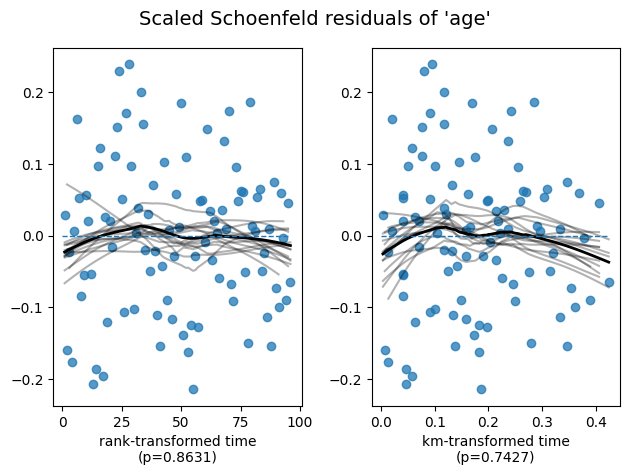

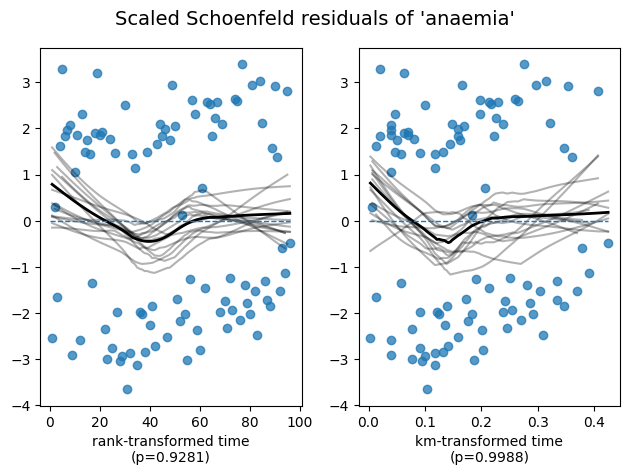

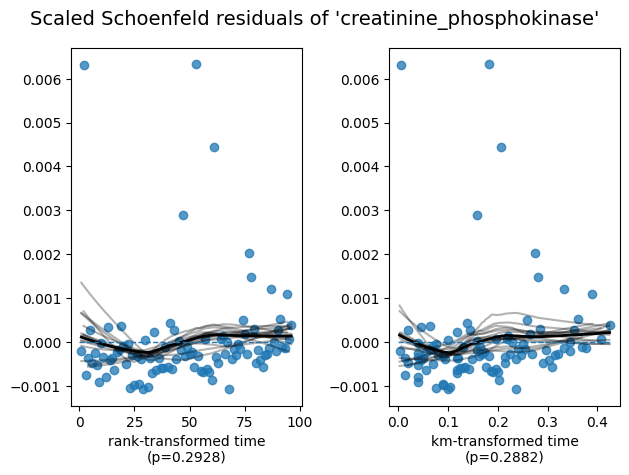

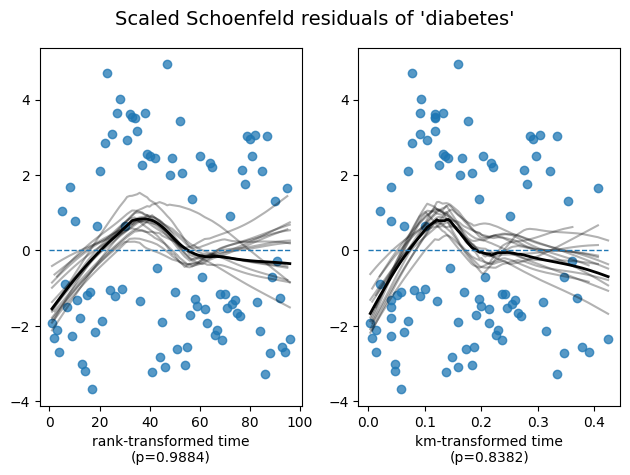

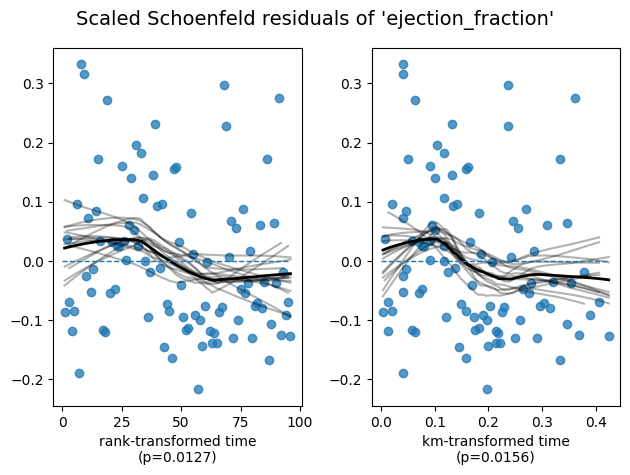

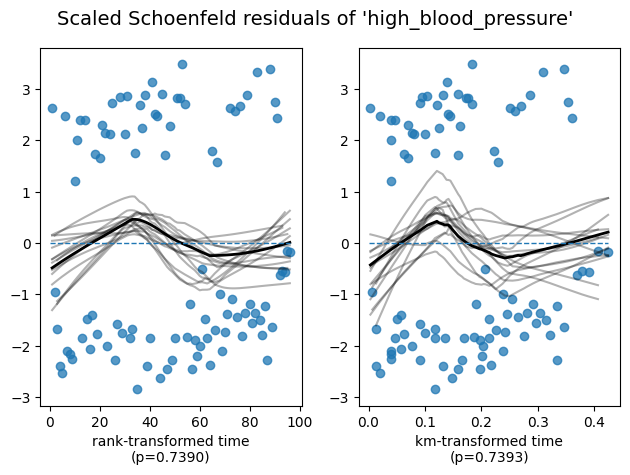

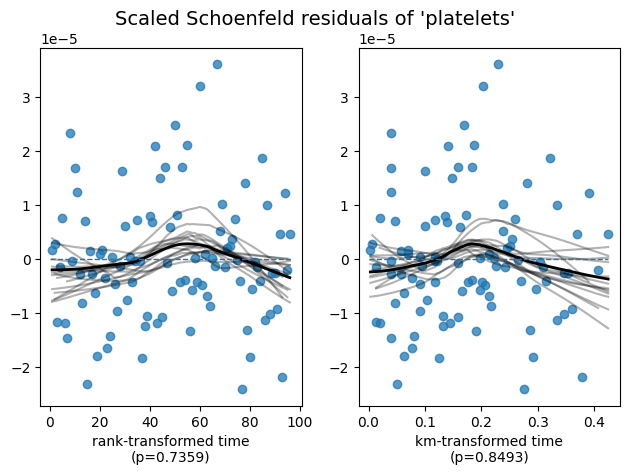

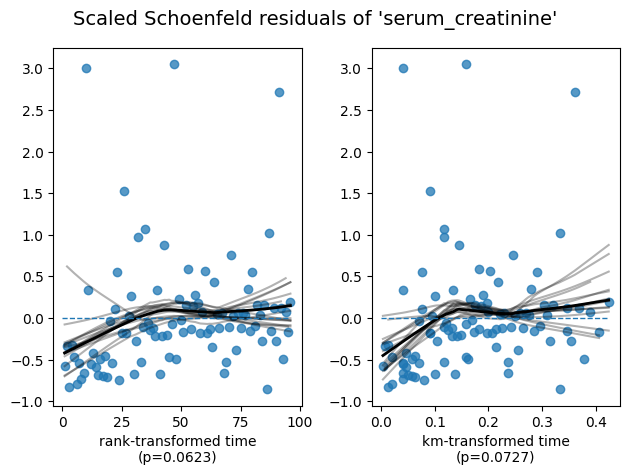

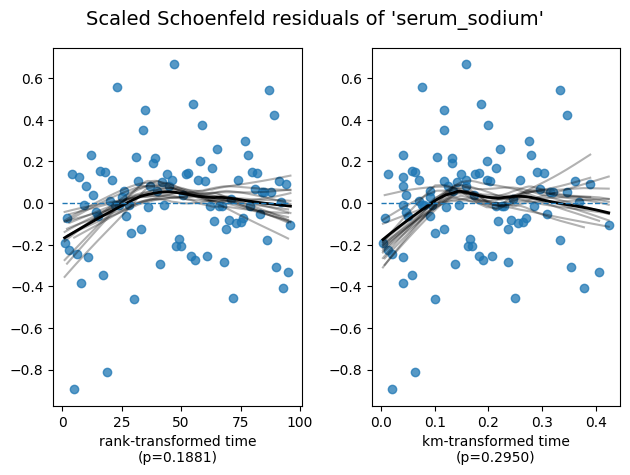

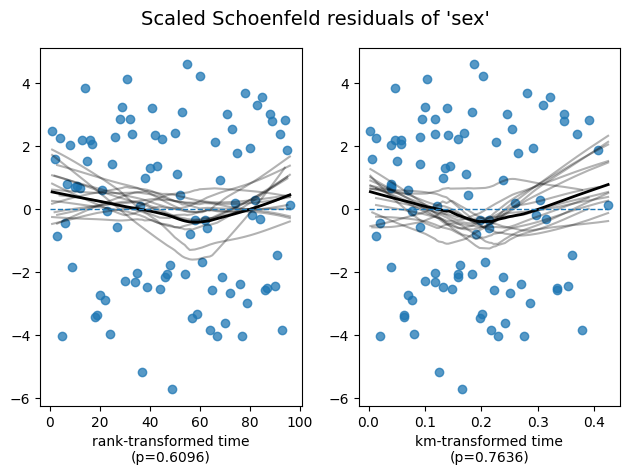

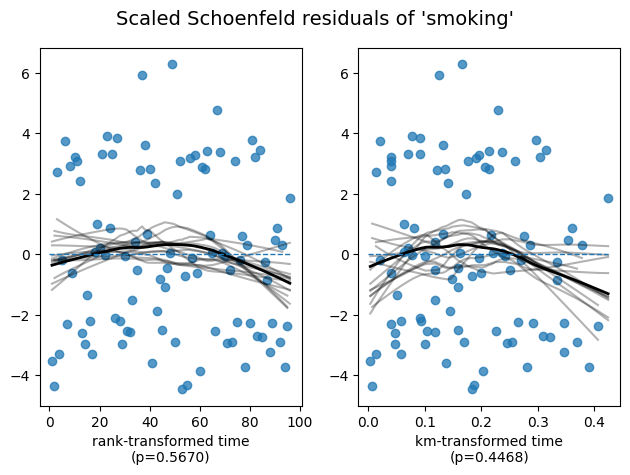

In [12]:
# =========================================================
# COX PROPORTIONAL HAZARDS MODEL
# PH ASSUMPTION CHECK USING SCHONFELD RESIDUALS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter

# ---------------------------------------------------------
# 1. Load dataset
# ---------------------------------------------------------
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# Survival variables
time_col = "time"
event_col = "DEATH_EVENT"

# ---------------------------------------------------------
# 2. Select predictors
# ---------------------------------------------------------
predictors = [
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking"
]

cox_data = df[[time_col, event_col] + predictors].copy()

print("Shape of Cox dataset:", cox_data.shape)
print(cox_data.head())

# ---------------------------------------------------------
# 3. Fit initial Cox PH model
# ---------------------------------------------------------
cph = CoxPHFitter()
cph.fit(cox_data, duration_col=time_col, event_col=event_col)

# ---------------------------------------------------------
# 4. Print model summary
# ---------------------------------------------------------
print("\n===== COX PH MODEL SUMMARY =====")
cph.print_summary()

# Optional: summary table
cox_summary = cph.summary.copy()
cox_summary["HR"] = np.exp(cox_summary["coef"])
cox_summary["HR_lower_95"] = np.exp(cox_summary["coef lower 95%"])
cox_summary["HR_upper_95"] = np.exp(cox_summary["coef upper 95%"])

print("\n===== HAZARD RATIOS =====")
print(cox_summary[[
    "coef",
    "exp(coef)",
    "se(coef)",
    "p",
    "HR",
    "HR_lower_95",
    "HR_upper_95"
]])

# ---------------------------------------------------------
# 5. Check proportional hazards assumption
# ---------------------------------------------------------
print("\n===== CHECKING PH ASSUMPTION =====")
cph.check_assumptions(cox_data, p_value_threshold=0.05, show_plots=True)

Standard Cox model fitted.


<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -468.23
         time fit was run = 2026-04-13 04:39:11 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
age                       0.05      1.05      0.01            0.03            0.06                1.03                1.07
anaemia                   0.46      1.58      0.22            0.04            0.89                1.04                2.42
creatinine_phosphokinase  0.00      1.00      0.00            0.00            0.00                1.00                1.00
diabetes                  0.14      1.15      0.22           -0.30            0.58                0.74                1.78
ejection_fraction        -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
high_blood_pressure       0.48      1.61      0.22            0.05            0.90                1.05                2.46
platelets                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
serum_creatinine          0.32      1.38      0.07            0.18            0.46                1.20                1.58
serum_sodium             -0.04      0.96      0.02           -0.09            0.00                0.91                1.00
sex                      -0.24      0.79      0.25           -0.73            0.26                0.48                1.29
smoking                   0.13      1.14      0.25           -0.36            0.62                0.70                1.86

                          cmp to     z      p  -log2(p)
covariate                                              
age                         0.00  4.98 <0.005     20.56
anaemia                     0.00  2.12   0.03      4.89
creatinine_phosphokinase    0.00  2.23   0.03      5.26
diabetes                    0.00  0.63   0.53      0.91
ejection_fraction           0.00 -4.67 <0.005     18.35
high_blood_pressure         0.00  2.20   0.03      5.17
platelets                   0.00 -0.41   0.68      0.56
serum_creatinine            0.00  4.58 <0.005     17.68
serum_sodium                0.00 -1.90   0.06      4.12
sex                         0.00 -0.94   0.35      1.53
smoking                     0.00  0.51   0.61      0.72
---
Concordance = 0.74
Partial AIC = 958.46
log-likelihood ratio test = 81.95 on 11 df
-log2(p) of ll-ratio test = 40.56

   time  DEATH_EVENT  martingale
0   4.0         True    0.987369
1   6.0         True    0.992337
2   7.0         True    0.981346
3   7.0         True    0.989299
4   8.0         True    0.852351


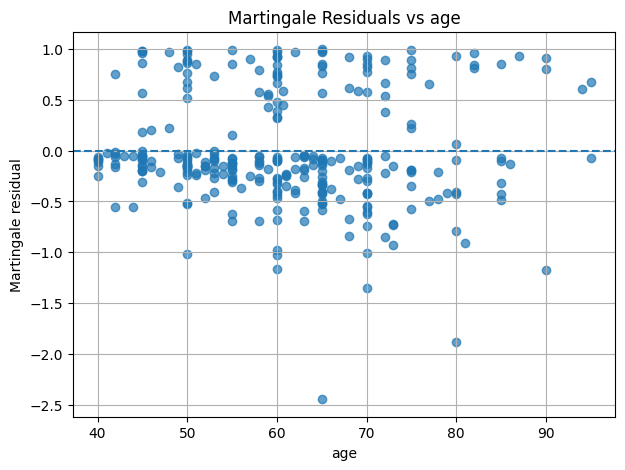

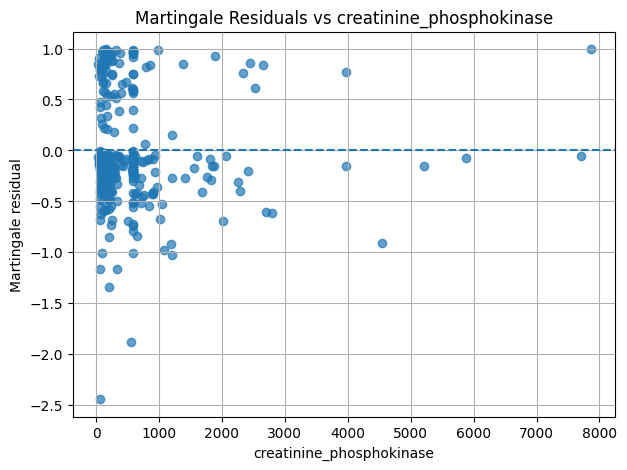

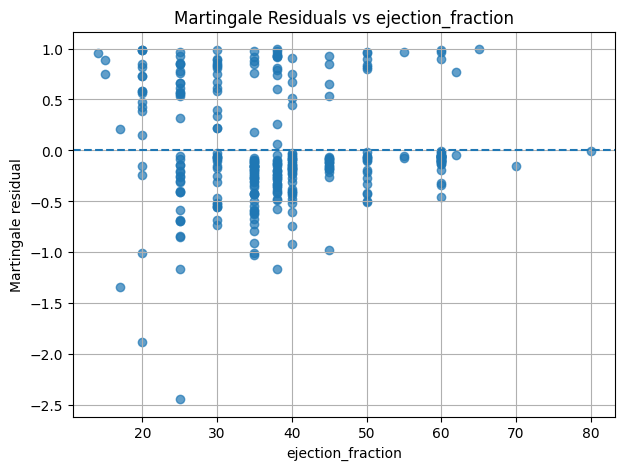

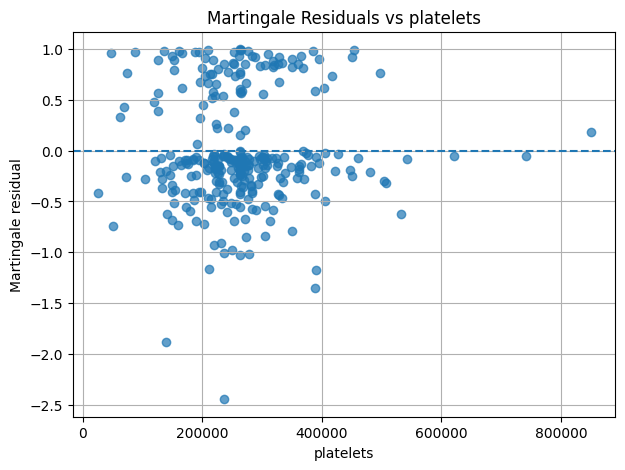

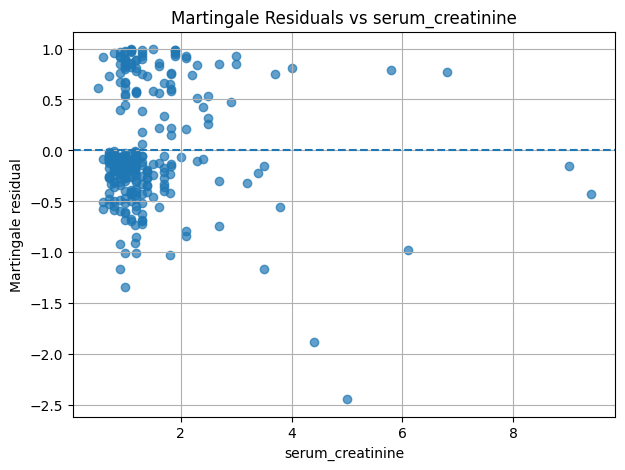

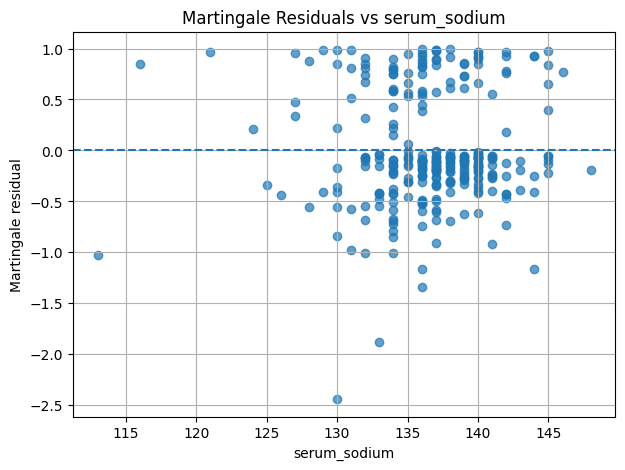

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# --------------------------------------------------
# 1. Load data
# --------------------------------------------------
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

time_col = "time"
event_col = "DEATH_EVENT"

predictors = [
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking"
]

continuous_vars = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

cox_data = df[[time_col, event_col] + predictors].copy()

# --------------------------------------------------
# 2. Fit standard Cox PH model
# --------------------------------------------------
cph = CoxPHFitter()
cph.fit(cox_data, duration_col=time_col, event_col=event_col)

print("Standard Cox model fitted.")
cph.print_summary()

# --------------------------------------------------
# 3. Compute Martingale residuals
# --------------------------------------------------
martingale_resid = cph.compute_residuals(cox_data, kind="martingale")

# lifelines returns a dataframe with columns like:
# 'time', 'DEATH_EVENT', 'martingale'
print(martingale_resid.head())

# merge with original continuous variables
martingale_df = cox_data.copy()
martingale_df["martingale_residual"] = martingale_resid["martingale"].values

# --------------------------------------------------
# 4. Plot Martingale residuals vs each continuous variable
# --------------------------------------------------
for var in continuous_vars:
    plt.figure(figsize=(7, 5))
    plt.scatter(martingale_df[var], martingale_df["martingale_residual"], alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel(var)
    plt.ylabel("Martingale residual")
    plt.title(f"Martingale Residuals vs {var}")
    plt.grid(True)
    plt.savefig(f"martingale_{var}.png", dpi=300, bbox_inches="tight")
    plt.show()

Shape: (299, 13)
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6       

<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -468.23
         time fit was run = 2026-04-14 03:14:31 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
age                       0.05      1.05      0.01            0.03            0.06                1.03                1.07
anaemia                   0.46      1.58      0.22            0.04            0.89                1.04                2.42
creatinine_phosphokinase  0.00      1.00      0.00            0.00            0.00                1.00                1.00
diabetes                  0.14      1.15      0.22           -0.30            0.58                0.74                1.78
ejection_fraction        -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
high_blood_pressure       0.48      1.61      0.22            0.05            0.90                1.05                2.46
platelets                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
serum_creatinine          0.32      1.38      0.07            0.18            0.46                1.20                1.58
serum_sodium             -0.04      0.96      0.02           -0.09            0.00                0.91                1.00
sex                      -0.24      0.79      0.25           -0.73            0.26                0.48                1.29
smoking                   0.13      1.14      0.25           -0.36            0.62                0.70                1.86

                          cmp to     z      p  -log2(p)
covariate                                              
age                         0.00  4.98 <0.005     20.56
anaemia                     0.00  2.12   0.03      4.89
creatinine_phosphokinase    0.00  2.23   0.03      5.26
diabetes                    0.00  0.63   0.53      0.91
ejection_fraction           0.00 -4.67 <0.005     18.35
high_blood_pressure         0.00  2.20   0.03      5.17
platelets                   0.00 -0.41   0.68      0.56
serum_creatinine            0.00  4.58 <0.005     17.68
serum_sodium                0.00 -1.90   0.06      4.12
sex                         0.00 -0.94   0.35      1.53
smoking                     0.00  0.51   0.61      0.72
---
Concordance = 0.74
Partial AIC = 958.46
log-likelihood ratio test = 81.95 on 11 df
-log2(p) of ll-ratio test = 40.56


MODEL B: TRANSFORMED STANDARD COX


<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -468.43
         time fit was run = 2026-04-14 03:14:32 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
age                   0.04      1.05      0.01            0.03            0.06                1.03                1.06
anaemia               0.45      1.57      0.21            0.03            0.86                1.03                2.37
log_cpk               0.09      1.09      0.10           -0.11            0.28                0.90                1.32
diabetes              0.15      1.16      0.22           -0.29            0.58                0.75                1.79
ejection_fraction    -0.04      0.96      0.01           -0.06           -0.02                0.94                0.98
high_blood_pressure   0.49      1.63      0.21            0.07            0.91                1.07                2.48
platelets            -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
log_serum_creatinine  1.39      4.02      0.30            0.80            1.98                2.22                7.25
serum_sodium         -0.04      0.97      0.02           -0.08            0.01                0.92                1.01
sex                  -0.25      0.78      0.25           -0.74            0.25                0.48                1.28
smoking               0.20      1.22      0.25           -0.30            0.69                0.74                2.00

                      cmp to     z      p  -log2(p)
covariate                                          
age                     0.00  4.64 <0.005     18.13
anaemia                 0.00  2.11   0.03      4.84
log_cpk                 0.00  0.87   0.38      1.38
diabetes                0.00  0.66   0.51      0.97
ejection_fraction       0.00 -4.27 <0.005     15.65
high_blood_pressure     0.00  2.28   0.02      5.47
platelets               0.00 -0.36   0.72      0.47
log_serum_creatinine    0.00  4.61 <0.005     17.91
serum_sodium            0.00 -1.50   0.13      2.91
sex                     0.00 -0.99   0.32      1.62
smoking                 0.00  0.78   0.44      1.20
---
Concordance = 0.74
Partial AIC = 958.86
log-likelihood ratio test = 81.55 on 11 df
-log2(p) of ll-ratio test = 40.30


STANDARD MODEL COMPARISON
                      Model  Log-Likelihood       AIC  C-index
0     Original Standard Cox       -468.2279  958.4557   0.7408
1  Transformed Standard Cox       -468.4314  958.8628   0.7370

Saved: comparison_standard_models.csv

PH ASSUMPTION CHECK: MODEL B

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
         test_name = proportional_hazard_test

---
                           test_statistic    p  -log2(p)
age                  km              0.35 0.55      0.86
                     rank            0.20 0.66      0.61
anaemia              km              0.05 0.83      0.27
                     rank            0.01 0.91      0.13
diabetes             km              0.06 0.81      0.30
                     rank            0.00 0.97      0.05
ejection_fraction    km              5.05 0.02      5.35
                     rank            5.37 0.02      5.61
high_blood_pressure  km              0.06 0.81      0.30
                     rank            0.06 0.81      0.31
log_cpk              km              4.48 0.03      4.87
                     rank            4.25 0.04      4.67
log_serum_creatinine km              3.39 0.07      3.93
                     rank            3.68 0.06      4.18
platelets            km              0.05 0.82      0.28
                     rank            0.12 0.73      0.46
serum_sodium         km              1.29 0.26      1.97
                     rank            1.98 0.16      2.65
sex                  km              0.33 0.57      0.82
                     rank            0.60 0.44      1.19
smoking              km              0.48 0.49      1.03
                     rank            0.25 0.62      0.70



1. Variable 'log_cpk' failed the non-proportional test: p-value is 0.0342.

   Advice 1: the functional form of the variable 'log_cpk' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'log_cpk' using pd.cut, and then specify it in
`strata=['log_cpk', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


2. Variable 'ejection_fraction' failed the non-proportional test: p-value is 0.0205.

   Advice 1: the functional form of the variable 'ejection_fraction' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard tes

<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -303.35
         time fit was run = 2026-04-14 03:14:39 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
age                     0.03      1.03      0.01            0.01            0.05                1.01                1.05
anaemia                 0.27      1.31      0.22           -0.17            0.71                0.85                2.04
log_cpk                 0.15      1.16      0.10           -0.05            0.35                0.95                1.42
diabetes               -0.14      0.87      0.24           -0.61            0.33                0.54                1.40
ejection_fraction       0.41      1.51      0.03            0.35            0.48                1.41                1.62
high_blood_pressure     0.37      1.45      0.24           -0.10            0.84                0.90                2.31
platelets              -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
log_serum_creatinine    0.92      2.52      0.34            0.25            1.60                1.28                4.94
serum_sodium           -0.00      1.00      0.02           -0.05            0.05                0.95                1.05
sex                    -0.21      0.81      0.27           -0.74            0.32                0.48                1.38
smoking                 0.01      1.01      0.26           -0.50            0.53                0.61                1.69
ejection_fraction_logt -0.12      0.89      0.01           -0.13           -0.10                0.87                0.91

                        cmp to      z      p  -log2(p)
covariate                                             
age                       0.00   2.85 <0.005      7.86
anaemia                   0.00   1.21   0.23      2.15
log_cpk                   0.00   1.45   0.15      2.77
diabetes                  0.00  -0.58   0.56      0.83
ejection_fraction         0.00  11.95 <0.005    106.90
high_blood_pressure       0.00   1.54   0.12      3.02
platelets                 0.00  -0.32   0.75      0.41
log_serum_creatinine      0.00   2.69   0.01      7.12
serum_sodium              0.00  -0.10   0.92      0.11
sex                       0.00  -0.77   0.44      1.18
smoking                   0.00   0.05   0.96      0.06
ejection_fraction_logt    0.00 -12.98 <0.005    125.50
---
Concordance = 0.96
Partial AIC = 630.70
log-likelihood ratio test = 411.71 on 12 df
-log2(p) of ll-ratio test = 265.43


FINAL MODEL COMPARISON
                        Model  Log-Likelihood       AIC  C-index
0       Original Standard Cox       -468.2279  958.4557   0.7408
1    Transformed Standard Cox       -468.4314  958.8628   0.7370
2  Extended Cox (Transformed)       -303.3523  630.7046   0.9625

Saved: final_model_comparison_option2.csv


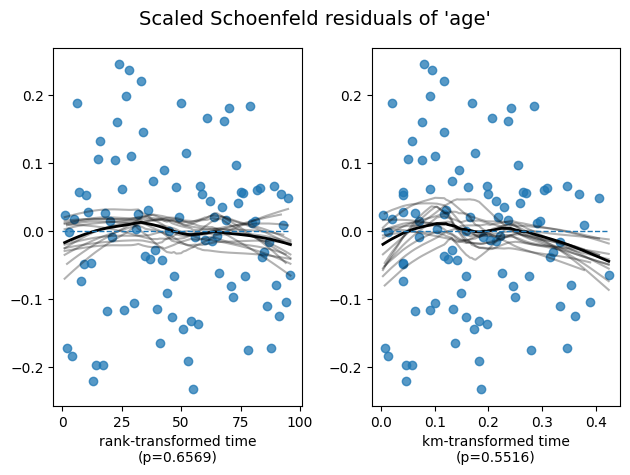

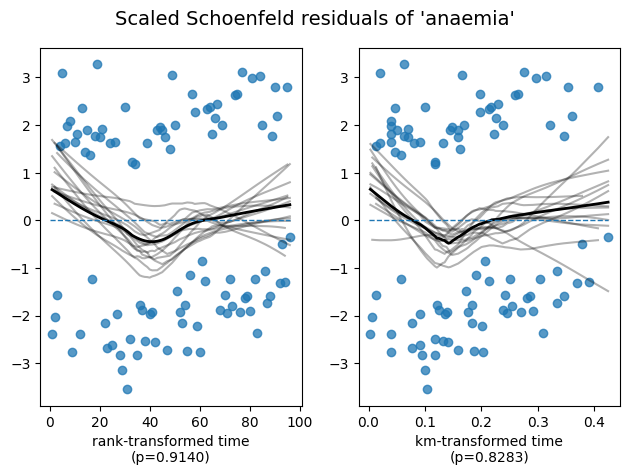

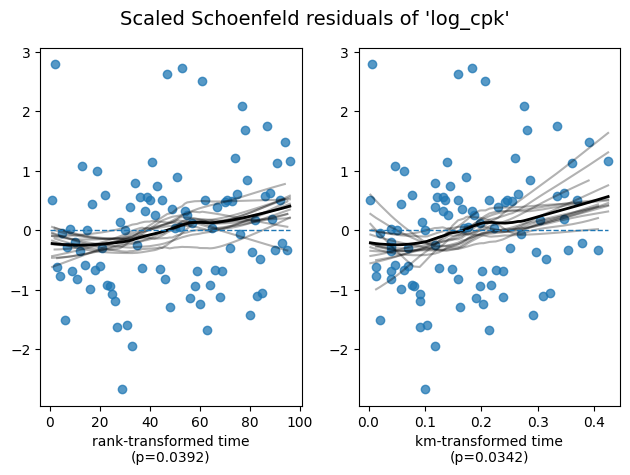

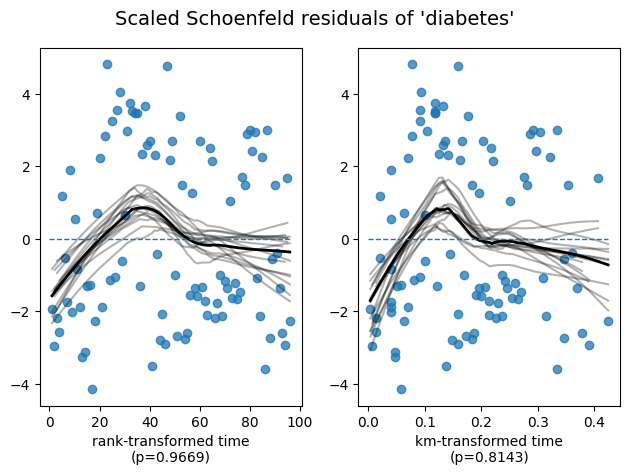

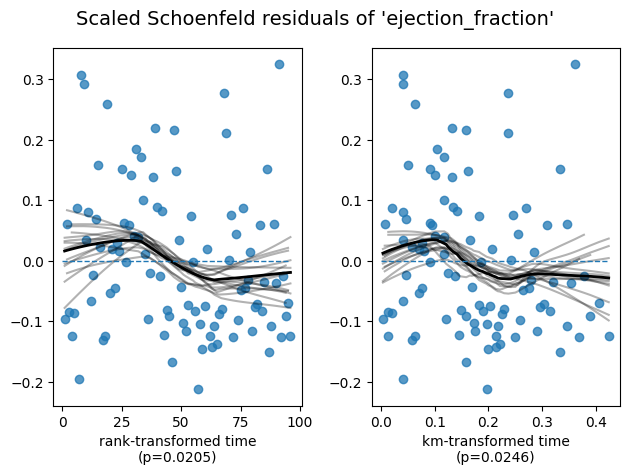

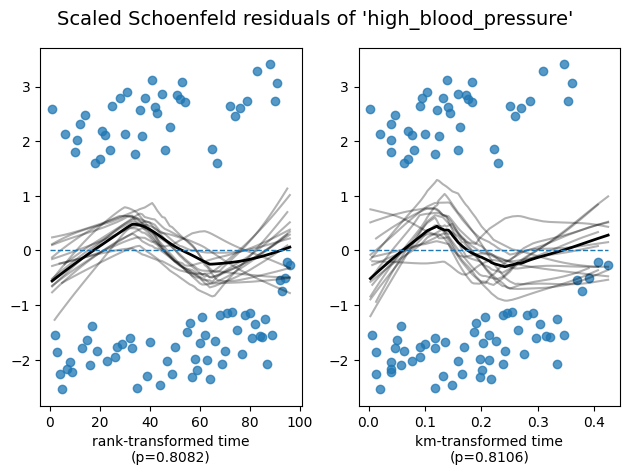

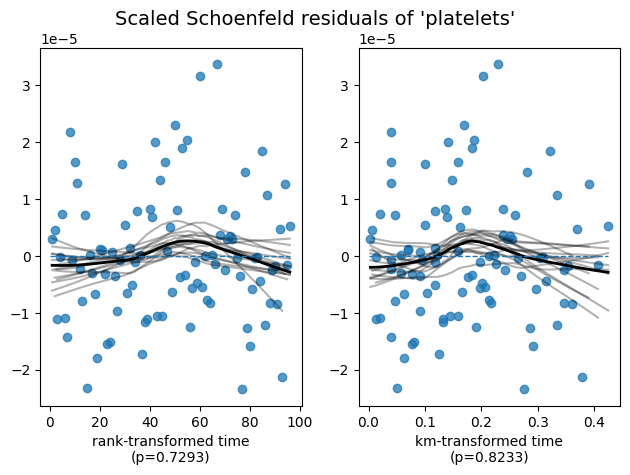

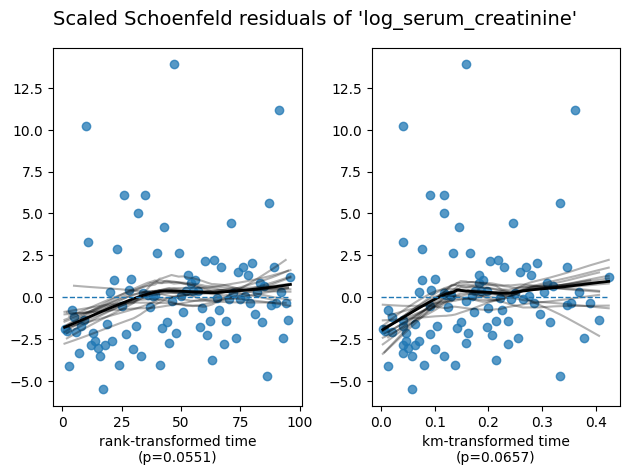

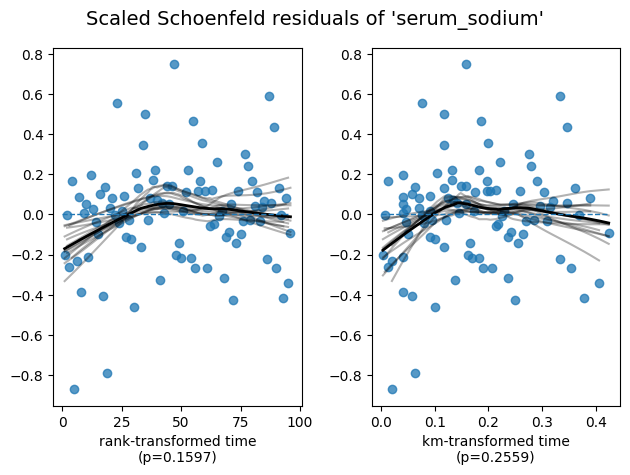

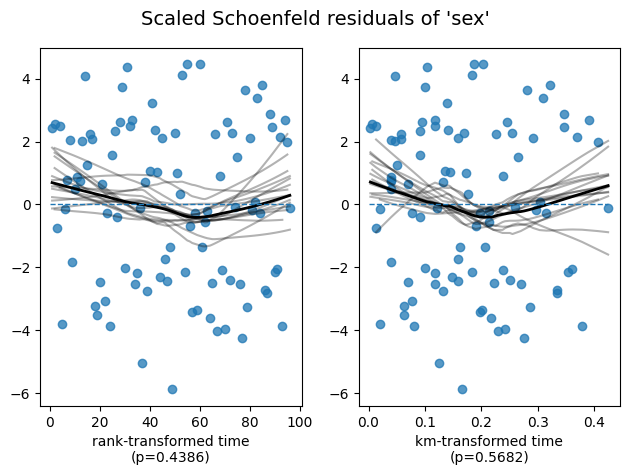

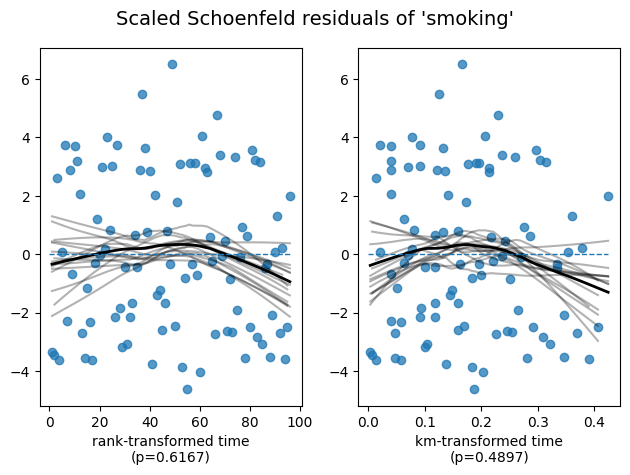

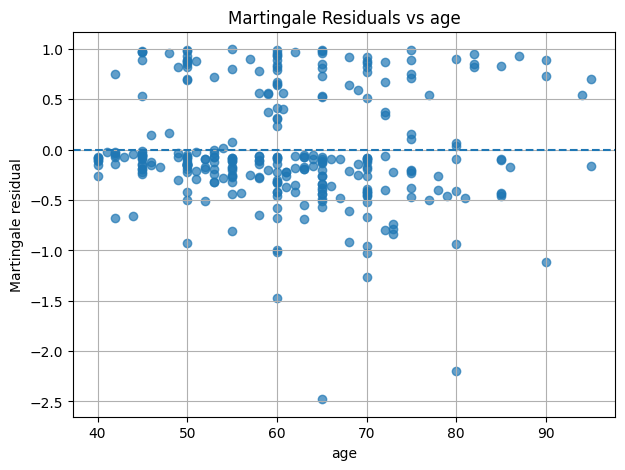

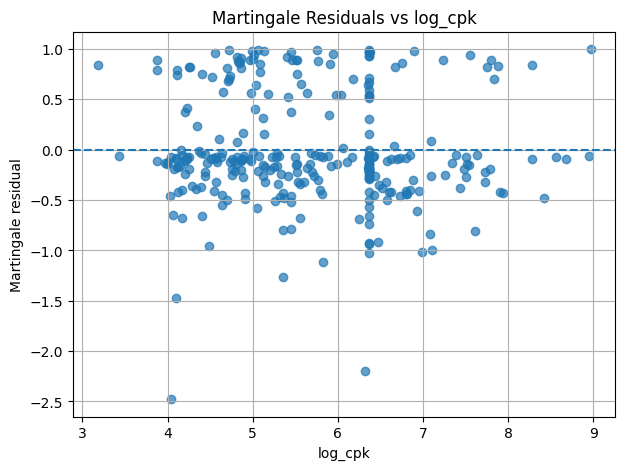

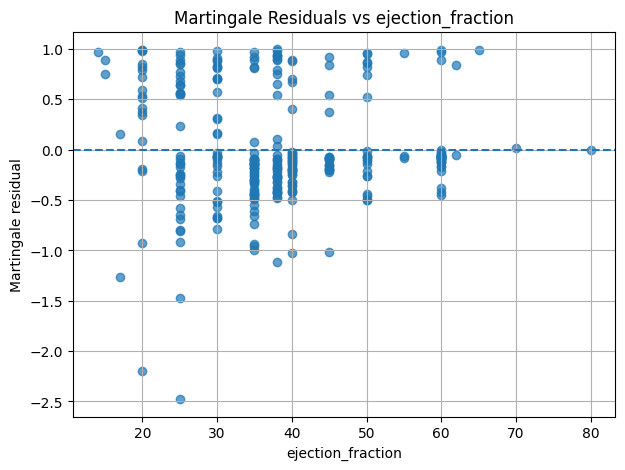

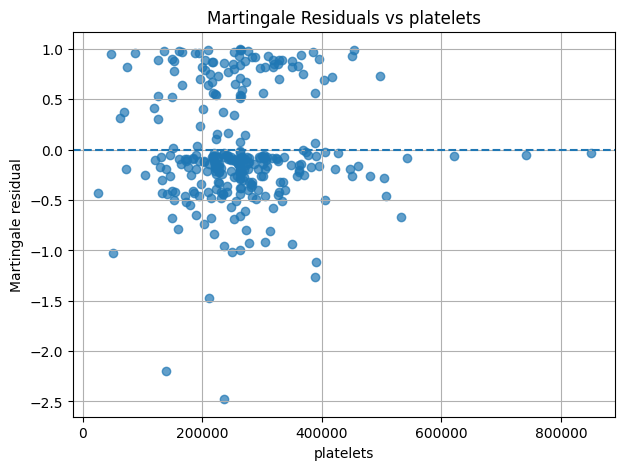

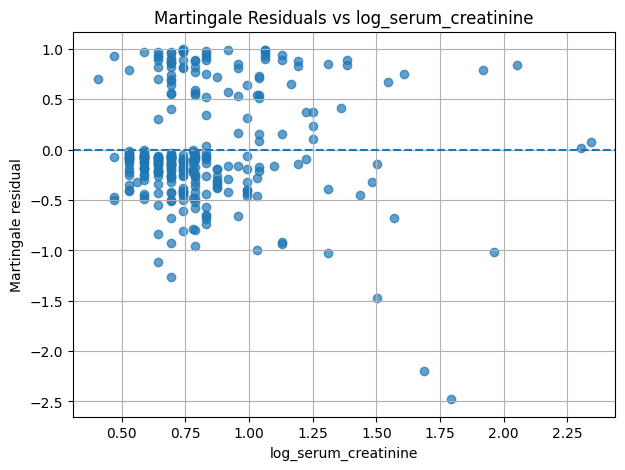

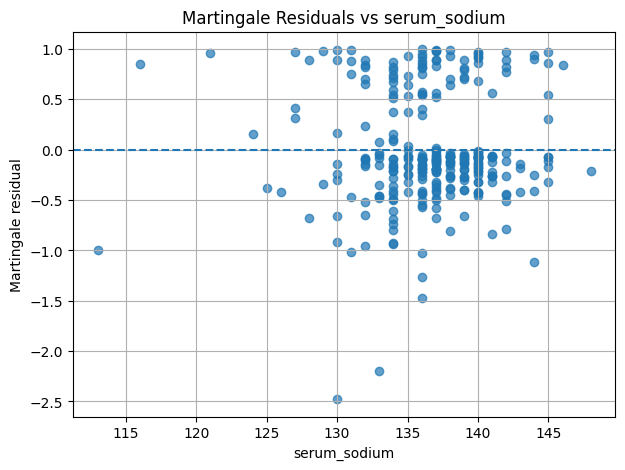


Saved Martingale plots for transformed model.


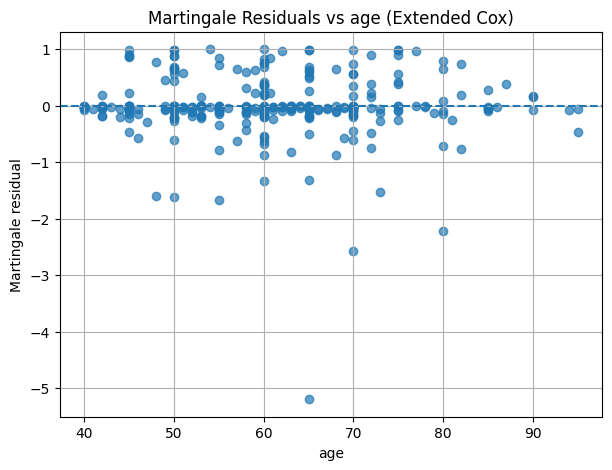

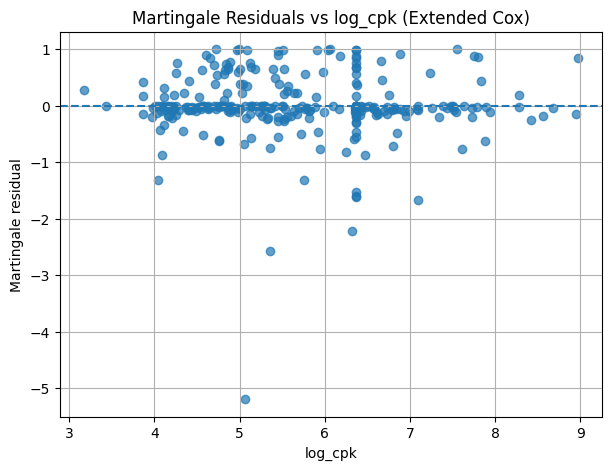

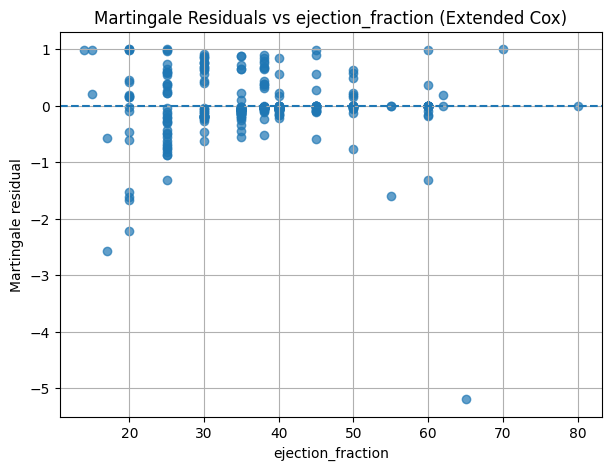

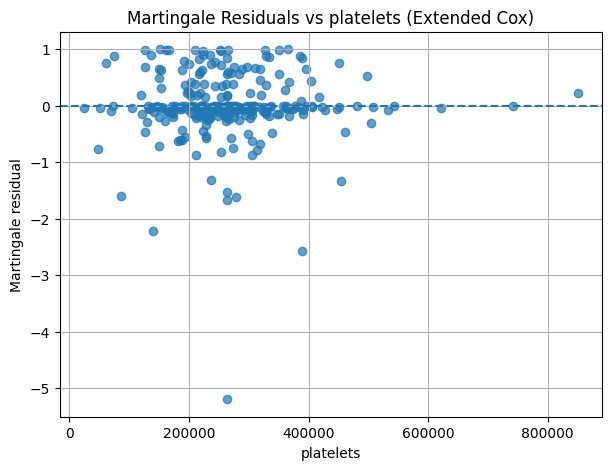

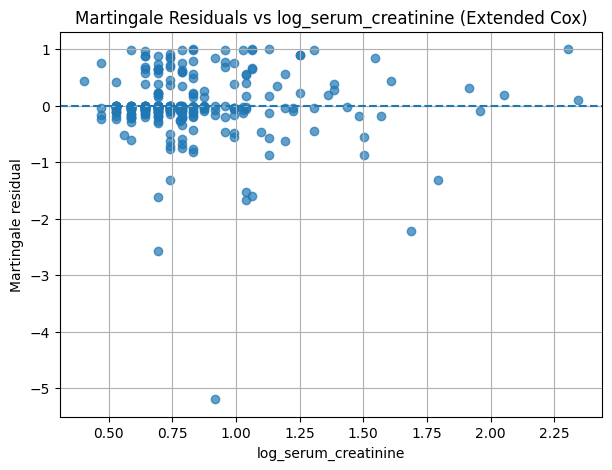

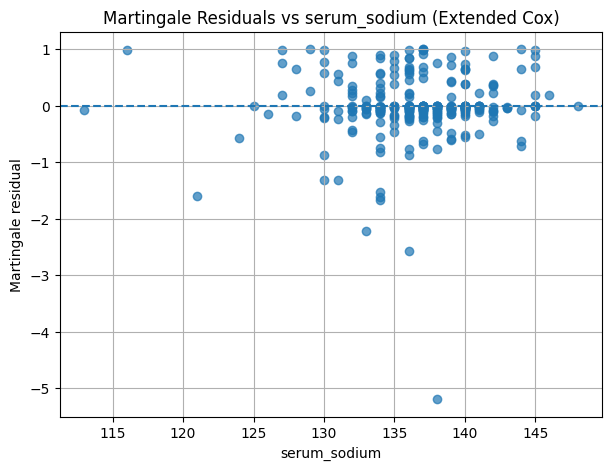


Saved Martingale plots for extended transformed model.

Saved:
- cox_original_summary.csv
- cox_transformed_summary.csv
- cox_extended_transformed_summary.csv


In [1]:
# =========================================================
# OPTION 2: TRANSFORM CONTINUOUS VARIABLES AND REFIT MODELS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

time_col = "time"
event_col = "DEATH_EVENT"

print("Shape:", df.shape)
print(df.head())

# ---------------------------------------------------------
# 2. Create transformed variables
#    log1p(x) = log(1+x), safer if variable contains small values
# ---------------------------------------------------------
df["log_cpk"] = np.log1p(df["creatinine_phosphokinase"])
df["log_serum_creatinine"] = np.log1p(df["serum_creatinine"])

print("\nCreated transformed variables:")
print(df[["creatinine_phosphokinase", "log_cpk",
          "serum_creatinine", "log_serum_creatinine"]].head())

# ---------------------------------------------------------
# 3. MODEL A: Original Standard Cox PH
# ---------------------------------------------------------
original_predictors = [
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking"
]

original_data = df[[time_col, event_col] + original_predictors].copy()

cph_original = CoxPHFitter()
cph_original.fit(original_data, duration_col=time_col, event_col=event_col)

print("\n==============================")
print("MODEL A: ORIGINAL STANDARD COX")
print("==============================")
cph_original.print_summary()

# ---------------------------------------------------------
# 4. MODEL B: Transformed Standard Cox PH
#    Replace CPK and serum_creatinine with transformed versions
# ---------------------------------------------------------
transformed_predictors = [
    "age",
    "anaemia",
    "log_cpk",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "log_serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking"
]

transformed_data = df[[time_col, event_col] + transformed_predictors].copy()

cph_transformed = CoxPHFitter()
cph_transformed.fit(transformed_data, duration_col=time_col, event_col=event_col)

print("\n=================================")
print("MODEL B: TRANSFORMED STANDARD COX")
print("=================================")
cph_transformed.print_summary()

# ---------------------------------------------------------
# 5. Compare MODEL A vs MODEL B
# ---------------------------------------------------------
comparison_standard = pd.DataFrame([
    {
        "Model": "Original Standard Cox",
        "Log-Likelihood": cph_original.log_likelihood_,
        "AIC": cph_original.AIC_partial_,
        "C-index": cph_original.concordance_index_
    },
    {
        "Model": "Transformed Standard Cox",
        "Log-Likelihood": cph_transformed.log_likelihood_,
        "AIC": cph_transformed.AIC_partial_,
        "C-index": cph_transformed.concordance_index_
    }
])

comparison_standard = comparison_standard.round(4)

print("\n=================================")
print("STANDARD MODEL COMPARISON")
print("=================================")
print(comparison_standard)

comparison_standard.to_csv("comparison_standard_models.csv", index=False)
print("\nSaved: comparison_standard_models.csv")

# ---------------------------------------------------------
# 6. Check PH assumption for transformed standard Cox
# ---------------------------------------------------------
print("\n=================================")
print("PH ASSUMPTION CHECK: MODEL B")
print("=================================")
cph_transformed.check_assumptions(
    transformed_data,
    p_value_threshold=0.05,
    show_plots=True
)

# ---------------------------------------------------------
# 7. MODEL C: Extended Cox using transformed variables
#    Since ejection_fraction violated PH, add time interaction
# ---------------------------------------------------------
df_ext = df[[time_col, event_col] + transformed_predictors].copy()

# representative time interaction basis
df_ext["log_time"] = np.log(df_ext[time_col] + 1)

# time-dependent effect for ejection_fraction
df_ext["ejection_fraction_logt"] = df_ext["ejection_fraction"] * df_ext["log_time"]

# Optional:
# if you still want to test time-dependence for transformed serum creatinine,
# uncomment below
# df_ext["log_serum_creatinine_logt"] = (
#     df_ext["log_serum_creatinine"] * df_ext["log_time"]
# )

extended_predictors = transformed_predictors + ["ejection_fraction_logt"]

ext_data = df_ext[[time_col, event_col] + extended_predictors].copy()

cph_extended = CoxPHFitter()
cph_extended.fit(ext_data, duration_col=time_col, event_col=event_col)

print("\n=================================")
print("MODEL C: EXTENDED COX (TRANSFORMED)")
print("=================================")
cph_extended.print_summary()

# ---------------------------------------------------------
# 8. Compare all 3 models
# ---------------------------------------------------------
final_comparison = pd.DataFrame([
    {
        "Model": "Original Standard Cox",
        "Log-Likelihood": cph_original.log_likelihood_,
        "AIC": cph_original.AIC_partial_,
        "C-index": cph_original.concordance_index_
    },
    {
        "Model": "Transformed Standard Cox",
        "Log-Likelihood": cph_transformed.log_likelihood_,
        "AIC": cph_transformed.AIC_partial_,
        "C-index": cph_transformed.concordance_index_
    },
    {
        "Model": "Extended Cox (Transformed)",
        "Log-Likelihood": cph_extended.log_likelihood_,
        "AIC": cph_extended.AIC_partial_,
        "C-index": cph_extended.concordance_index_
    }
])

final_comparison = final_comparison.round(4)

print("\n=================================")
print("FINAL MODEL COMPARISON")
print("=================================")
print(final_comparison)

final_comparison.to_csv("final_model_comparison_option2.csv", index=False)
print("\nSaved: final_model_comparison_option2.csv")

# ---------------------------------------------------------
# 9. Martingale residual plots for transformed standard Cox
#    Use these to check whether transformation improved form
# ---------------------------------------------------------
martingale_resid = cph_transformed.compute_residuals(transformed_data, kind="martingale")

martingale_df = transformed_data.copy()
martingale_df["martingale_residual"] = martingale_resid["martingale"].values

vars_for_martingale = [
    "age",
    "log_cpk",
    "ejection_fraction",
    "platelets",
    "log_serum_creatinine",
    "serum_sodium"
]

for var in vars_for_martingale:
    plt.figure(figsize=(7, 5))
    plt.scatter(martingale_df[var], martingale_df["martingale_residual"], alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel(var)
    plt.ylabel("Martingale residual")
    plt.title(f"Martingale Residuals vs {var}")
    plt.grid(True)
    plt.savefig(f"martingale_transformed_{var}.png", dpi=300, bbox_inches="tight")
    plt.show()

print("\nSaved Martingale plots for transformed model.")

# ---------------------------------------------------------
# 10. Optional: Martingale residuals for final extended model
# ---------------------------------------------------------
martingale_resid_ext = cph_extended.compute_residuals(ext_data, kind="martingale")

martingale_df_ext = ext_data.copy()
martingale_df_ext["martingale_residual"] = martingale_resid_ext["martingale"].values

vars_for_martingale_ext = [
    "age",
    "log_cpk",
    "ejection_fraction",
    "platelets",
    "log_serum_creatinine",
    "serum_sodium"
]

for var in vars_for_martingale_ext:
    plt.figure(figsize=(7, 5))
    plt.scatter(martingale_df_ext[var], martingale_df_ext["martingale_residual"], alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel(var)
    plt.ylabel("Martingale residual")
    plt.title(f"Martingale Residuals vs {var} (Extended Cox)")
    plt.grid(True)
    plt.savefig(f"martingale_extended_transformed_{var}.png", dpi=300, bbox_inches="tight")
    plt.show()

print("\nSaved Martingale plots for extended transformed model.")

# ---------------------------------------------------------
# 11. Export summaries
# ---------------------------------------------------------
cph_original.summary.to_csv("cox_original_summary.csv")
cph_transformed.summary.to_csv("cox_transformed_summary.csv")
cph_extended.summary.to_csv("cox_extended_transformed_summary.csv")

print("\nSaved:")
print("- cox_original_summary.csv")
print("- cox_transformed_summary.csv")
print("- cox_extended_transformed_summary.csv")

Extended Cox model fitted successfully.


<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -400.69
         time fit was run = 2026-04-14 04:53:49 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
age                       0.01      1.01      0.01           -0.01            0.02                0.99                1.02
anaemia                   0.03      1.03      0.23           -0.41            0.48                0.66                1.61
creatinine_phosphokinase  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
diabetes                 -0.08      0.92      0.23           -0.52            0.36                0.59                1.43
ejection_fraction         0.10      1.11      0.03            0.05            0.15                1.05                1.17
high_blood_pressure       0.02      1.03      0.24           -0.44            0.49                0.65                1.63
platelets                 0.00      1.00      0.00           -0.00            0.00                1.00                1.00
serum_creatinine          1.16      3.18      0.22            0.73            1.58                2.08                4.86
serum_sodium             -0.01      0.99      0.02           -0.06            0.03                0.94                1.03
sex                      -0.06      0.94      0.26           -0.56            0.45                0.57                1.56
smoking                  -0.01      0.99      0.26           -0.52            0.50                0.59                1.65
ejection_fraction_logt   -0.02      0.98      0.01           -0.04           -0.01                0.96                0.99
serum_creatinine_logt    -0.22      0.80      0.06           -0.35           -0.10                0.71                0.91

                          cmp to     z      p  -log2(p)
covariate                                              
age                         0.00  0.56   0.57      0.80
anaemia                     0.00  0.14   0.89      0.17
creatinine_phosphokinase    0.00  0.36   0.72      0.48
diabetes                    0.00 -0.36   0.72      0.48
ejection_fraction           0.00  3.81 <0.005     12.81
high_blood_pressure         0.00  0.11   0.92      0.13
platelets                   0.00  0.01   1.00      0.01
serum_creatinine            0.00  5.34 <0.005     23.36
serum_sodium                0.00 -0.60   0.55      0.87
sex                         0.00 -0.23   0.82      0.29
smoking                     0.00 -0.05   0.96      0.05
ejection_fraction_logt      0.00 -4.29 <0.005     15.78
serum_creatinine_logt       0.00 -3.53 <0.005     11.23
---
Concordance = 0.97
Partial AIC = 827.38
log-likelihood ratio test = 217.03 on 13 df
-log2(p) of ll-ratio test = 127.46

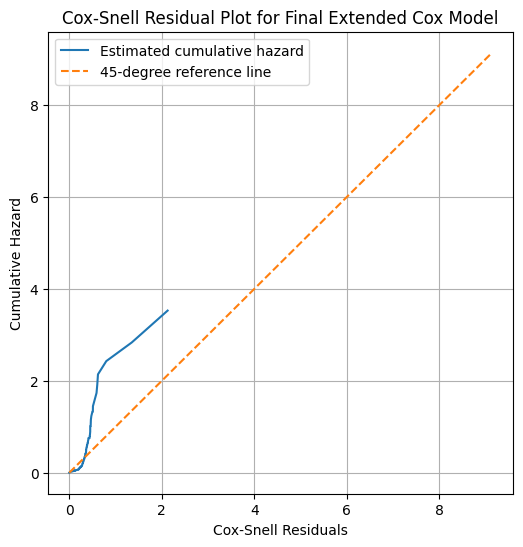

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter

# ---------------------------------------------------
# 1. Load data
# ---------------------------------------------------
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# ---------------------------------------------------
# 2. Create time-dependent terms
# ---------------------------------------------------
df["log_time"] = np.log(df["time"] + 1)
df["ejection_fraction_logt"] = df["ejection_fraction"] * df["log_time"]
df["serum_creatinine_logt"] = df["serum_creatinine"] * df["log_time"]

# ---------------------------------------------------
# 3. Final model variables
# ---------------------------------------------------
model_cols = [
    "time", "DEATH_EVENT",
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking",
    "ejection_fraction_logt",
    "serum_creatinine_logt"
]

ext_data = df[model_cols].copy()

# ---------------------------------------------------
# 4. Fit final extended Cox model
# ---------------------------------------------------
cph_extended = CoxPHFitter()
cph_extended.fit(ext_data, duration_col="time", event_col="DEATH_EVENT")

print("Extended Cox model fitted successfully.")
cph_extended.print_summary()

# ---------------------------------------------------
# 5. Cox-Snell residuals
# ---------------------------------------------------
# Predict cumulative hazard for each subject
cum_hazard = cph_extended.predict_cumulative_hazard(ext_data)

# Cox-Snell residual = estimated cumulative hazard at observed time
cox_snell_residuals = []

for i in range(len(ext_data)):
    observed_time = ext_data.iloc[i]["time"]
    subject_curve = cum_hazard.iloc[:, i]

    # get cumulative hazard value at closest observed time
    closest_time = subject_curve.index[subject_curve.index <= observed_time].max()
    cox_snell_residuals.append(subject_curve.loc[closest_time])

cox_snell_residuals = np.array(cox_snell_residuals)

# ---------------------------------------------------
# 6. Fit KM on Cox-Snell residuals
# ---------------------------------------------------
kmf = KaplanMeierFitter()
kmf.fit(cox_snell_residuals, event_observed=ext_data["DEATH_EVENT"])

# Estimated cumulative hazard of residuals
cum_hazard_resid = -np.log(kmf.survival_function_)

# ---------------------------------------------------
# 7. Plot Cox-Snell residuals
# ---------------------------------------------------
plt.figure(figsize=(6, 6))
plt.plot(cum_hazard_resid.index,
         cum_hazard_resid["KM_estimate"],
         label="Estimated cumulative hazard")

plt.plot(cum_hazard_resid.index,
         cum_hazard_resid.index,
         linestyle="--",
         label="45-degree reference line")

plt.xlabel("Cox-Snell Residuals")
plt.ylabel("Cumulative Hazard")
plt.title("Cox-Snell Residual Plot for Final Extended Cox Model")
plt.legend()
plt.grid(True)
plt.savefig("cox_snell_extended_final.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,log_time,ejection_fraction_logt,serum_creatinine_logt
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1,1.609438,32.188758,3.057932
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1,1.945910,73.944586,2.140501
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1,2.079442,41.588831,2.703274
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1,2.079442,41.588831,3.950939
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1,2.197225,43.944492,5.932506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0,5.602119,212.880515,6.162331
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0,5.605802,213.020479,6.726962
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0,5.631212,337.872707,4.504969
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0,5.638355,214.257477,7.893697


c:\Users\sayan\OneDrive\Desktop\Churn Survival\venv\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


Extended Cox model fitted successfully.


<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -400.69
         time fit was run = 2026-04-03 14:41:24 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
age                       0.01      1.01      0.01           -0.01            0.02                0.99                1.02
anaemia                   0.03      1.03      0.23           -0.41            0.48                0.66                1.61
creatinine_phosphokinase  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
diabetes                 -0.08      0.92      0.23           -0.52            0.36                0.59                1.43
ejection_fraction         0.10      1.11      0.03            0.05            0.15                1.05                1.17
high_blood_pressure       0.02      1.03      0.24           -0.44            0.49                0.65                1.63
platelets                 0.00      1.00      0.00           -0.00            0.00                1.00                1.00
serum_creatinine          1.16      3.18      0.22            0.73            1.58                2.08                4.86
serum_sodium             -0.01      0.99      0.02           -0.06            0.03                0.94                1.03
sex                      -0.06      0.94      0.26           -0.56            0.45                0.57                1.56
smoking                  -0.01      0.99      0.26           -0.52            0.50                0.59                1.65
ejection_fraction_logt   -0.02      0.98      0.01           -0.04           -0.01                0.96                0.99
serum_creatinine_logt    -0.22      0.80      0.06           -0.35           -0.10                0.71                0.91

                          cmp to     z      p  -log2(p)
covariate                                              
age                         0.00  0.56   0.57      0.80
anaemia                     0.00  0.14   0.89      0.17
creatinine_phosphokinase    0.00  0.36   0.72      0.48
diabetes                    0.00 -0.36   0.72      0.48
ejection_fraction           0.00  3.81 <0.005     12.81
high_blood_pressure         0.00  0.11   0.92      0.13
platelets                   0.00  0.01   1.00      0.01
serum_creatinine            0.00  5.34 <0.005     23.36
serum_sodium                0.00 -0.60   0.55      0.87
sex                         0.00 -0.23   0.82      0.29
smoking                     0.00 -0.05   0.96      0.05
ejection_fraction_logt      0.00 -4.29 <0.005     15.78
serum_creatinine_logt       0.00 -3.53 <0.005     11.23
---
Concordance = 0.97
Partial AIC = 827.38
log-likelihood ratio test = 217.03 on 13 df
-log2(p) of ll-ratio test = 127.46

Representative time used: 115.0
Representative log_time used: 4.7536


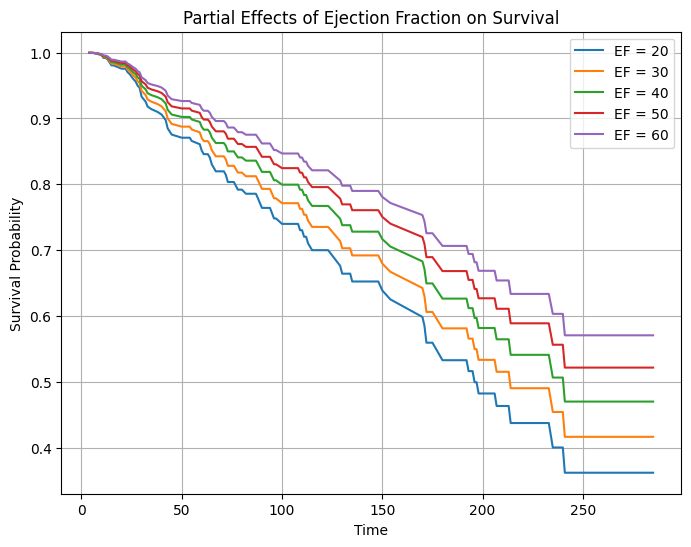

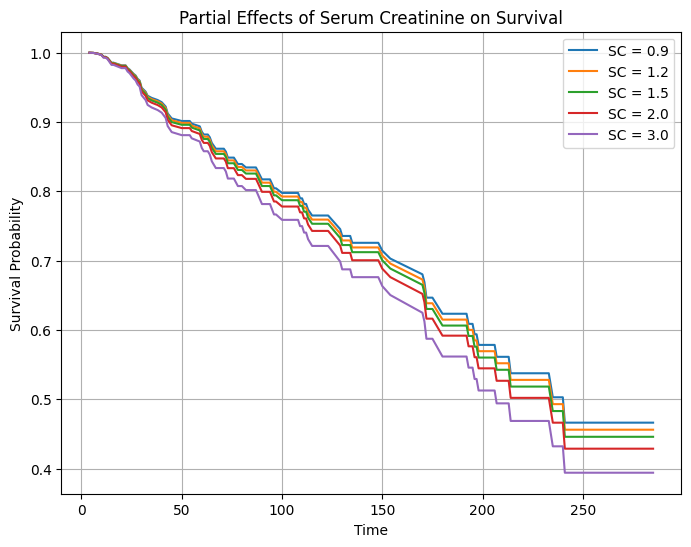

In [1]:
# =========================================================
# PARTIAL EFFECT PLOTS FROM EXTENDED COX MODEL
# For ejection_fraction and serum_creatinine
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

time_col = "time"
event_col = "DEATH_EVENT"

predictors = [
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking"
]

# ---------------------------------------------------------
# 2. Create extended Cox data
# ---------------------------------------------------------
df_ext = df[[time_col, event_col] + predictors].copy()
df_ext["log_time"] = np.log(df_ext[time_col] + 1)

df_ext["ejection_fraction_logt"] = df_ext["ejection_fraction"] * df_ext["log_time"]
df_ext["serum_creatinine_logt"] = df_ext["serum_creatinine"] * df_ext["log_time"]

ext_predictors = predictors + ["ejection_fraction_logt", "serum_creatinine_logt"]

# ---------------------------------------------------------
# 3. Fit extended Cox model
# ---------------------------------------------------------
cph_ext = CoxPHFitter()
cph_ext.fit(
    df_ext[[time_col, event_col] + ext_predictors],
    duration_col=time_col,
    event_col=event_col
)

print("Extended Cox model fitted successfully.")
cph_ext.print_summary()

# ---------------------------------------------------------
# 4. Choose representative covariate profile
#    Use median values for continuous variables
#    and mode for binary variables
# ---------------------------------------------------------
profile = pd.DataFrame(index=[0])

continuous_vars = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

binary_vars = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking"
]

for col in continuous_vars:
    profile[col] = df_ext[col].median()

for col in binary_vars:
    profile[col] = df_ext[col].mode()[0]

# ---------------------------------------------------------
# 5. Choose representative time level
#    Use median follow-up time
# ---------------------------------------------------------
rep_time = df_ext["time"].median()
rep_log_time = np.log(rep_time + 1)

print("Representative time used:", rep_time)
print("Representative log_time used:", round(rep_log_time, 4))

# ---------------------------------------------------------
# 6. Partial effect for ejection_fraction
# ---------------------------------------------------------
ef_values = [20, 30, 40, 50, 60]

ef_profiles = []

for val in ef_values:
    row = profile.copy()
    row["ejection_fraction"] = val
    row["serum_creatinine"] = df_ext["serum_creatinine"].median()

    # update interaction terms
    row["ejection_fraction_logt"] = val * rep_log_time
    row["serum_creatinine_logt"] = row["serum_creatinine"].iloc[0] * rep_log_time

    ef_profiles.append(row)

ef_profiles = pd.concat(ef_profiles, ignore_index=True)

ef_surv = cph_ext.predict_survival_function(ef_profiles)

plt.figure(figsize=(8, 6))
for i, val in enumerate(ef_values):
    plt.plot(ef_surv.index, ef_surv.iloc[:, i], label=f"EF = {val}")

plt.title("Partial Effects of Ejection Fraction on Survival")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.savefig("partial_effect_ejection_fraction_extended_cox.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 7. Partial effect for serum_creatinine
# ---------------------------------------------------------
sc_values = [0.9, 1.2, 1.5, 2.0, 3.0]

sc_profiles = []

for val in sc_values:
    row = profile.copy()
    row["serum_creatinine"] = val
    row["ejection_fraction"] = df_ext["ejection_fraction"].median()

    # update interaction terms
    row["serum_creatinine_logt"] = val * rep_log_time
    row["ejection_fraction_logt"] = row["ejection_fraction"].iloc[0] * rep_log_time

    sc_profiles.append(row)

sc_profiles = pd.concat(sc_profiles, ignore_index=True)

sc_surv = cph_ext.predict_survival_function(sc_profiles)

plt.figure(figsize=(8, 6))
for i, val in enumerate(sc_values):
    plt.plot(sc_surv.index, sc_surv.iloc[:, i], label=f"SC = {val}")

plt.title("Partial Effects of Serum Creatinine on Survival")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.savefig("partial_effect_serum_creatinine_extended_cox.png", dpi=300, bbox_inches="tight")
plt.show()

c:\Users\sayan\OneDrive\Desktop\Churn Survival\venv\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


Extended Cox model fitted successfully.

Saved: survival_probabilities_over_time_extended_cox.csv

First 10 time points:
      Patient-296  Patient-196  Patient-165  Patient-126     Patient-9
4.0      0.999961     0.999868     0.999746     0.999529  4.781296e-01
6.0      0.999922     0.999734     0.999490     0.999055  2.273043e-01
7.0      0.999842     0.999465     0.998973     0.998098  5.067448e-02
8.0      0.999762     0.999194     0.998453     0.997136  1.117800e-02
10.0     0.999516     0.998361     0.996858     0.994186  1.077190e-04
11.0     0.999013     0.996659     0.993598     0.988172  8.021017e-09
12.0     0.999013     0.996659     0.993598     0.988172  8.021017e-09
13.0     0.998747     0.995761     0.991880     0.985009  5.276868e-11
14.0     0.998193     0.993889     0.988304     0.978439  1.475820e-15
15.0     0.997623     0.991967     0.984640     0.971730  3.071462e-20

Last 10 time points:
       Patient-296  Patient-196  Patient-165  Patient-126  Patient-9
247.0  

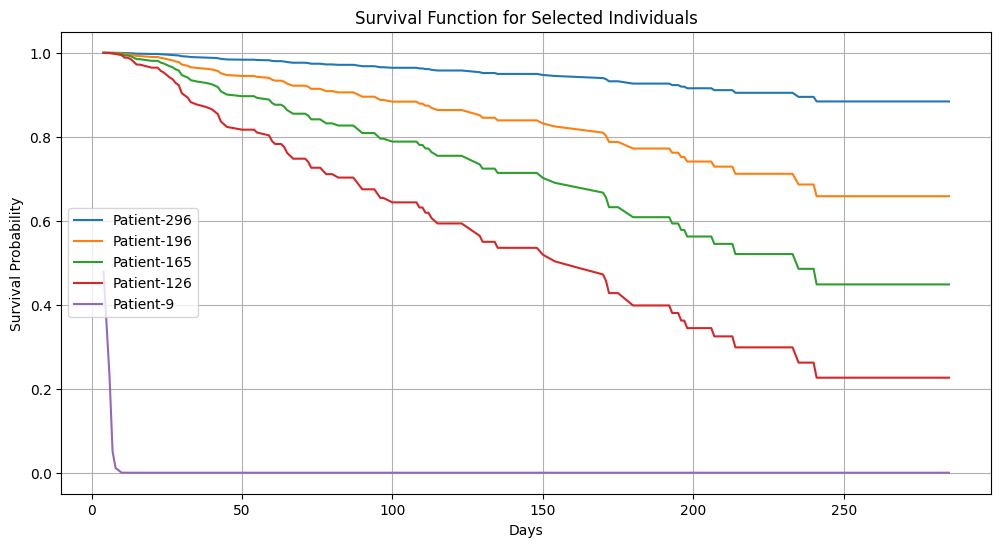

Saved: survival_function_selected_individuals_extended_cox.png


In [5]:
# =========================================================
# SURVIVAL PROBABILITIES OVER TIME FOR SELECTED PATIENTS
# USING EXTENDED COX MODEL
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

time_col = "time"
event_col = "DEATH_EVENT"

predictors = [
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking"
]

# ---------------------------------------------------------
# 2. Prepare extended Cox dataset
# ---------------------------------------------------------
df_ext = df[[time_col, event_col] + predictors].copy()

df_ext["log_time"] = np.log(df_ext[time_col] + 1)
df_ext["ejection_fraction_logt"] = df_ext["ejection_fraction"] * df_ext["log_time"]
df_ext["serum_creatinine_logt"] = df_ext["serum_creatinine"] * df_ext["log_time"]

ext_predictors = predictors + ["ejection_fraction_logt", "serum_creatinine_logt"]

# ---------------------------------------------------------
# 3. Fit extended Cox model
# ---------------------------------------------------------
cph_ext = CoxPHFitter()
cph_ext.fit(
    df_ext[[time_col, event_col] + ext_predictors],
    duration_col=time_col,
    event_col=event_col
)

print("Extended Cox model fitted successfully.")

# Auto-select 5 patients by risk
risk_scores = cph_ext.predict_partial_hazard(df_ext[ext_predictors])
df_risk = pd.DataFrame({"risk_score": risk_scores.values}, index=df_ext.index).sort_values("risk_score")

selected_idx = [
    df_risk.index[0],
    df_risk.index[len(df_risk)//4],
    df_risk.index[len(df_risk)//2],
    df_risk.index[3*len(df_risk)//4],
    df_risk.index[-1]
]

selected_data = df_ext.loc[selected_idx, ext_predictors].copy()
selected_data.index = [f"Patient-{i}" for i in selected_idx]

survival_function_data = cph_ext.predict_survival_function(selected_data)

# Save full table
survival_function_data.to_csv("survival_probabilities_over_time_extended_cox.csv")
print("\nSaved: survival_probabilities_over_time_extended_cox.csv")

# ---------------------------------------------------------
# 6. Extract first 10 and last 10 time points
# ---------------------------------------------------------
head_10 = survival_function_data.head(10)
tail_10 = survival_function_data.tail(10)

print("\nFirst 10 time points:")
print(head_10)

print("\nLast 10 time points:")
print(tail_10)

head_10.to_csv("survival_probabilities_first10_extended_cox.csv")
tail_10.to_csv("survival_probabilities_last10_extended_cox.csv")

print("\nSaved:")
print("- survival_probabilities_first10_extended_cox.csv")
print("- survival_probabilities_last10_extended_cox.csv")

# ---------------------------------------------------------
# 7. Plot survival probabilities over time
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
for col in survival_function_data.columns:
    plt.plot(survival_function_data.index, survival_function_data[col], label=col)

plt.title("Survival Function for Selected Individuals")
plt.xlabel("Days")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.savefig("survival_function_selected_individuals_extended_cox.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: survival_function_selected_individuals_extended_cox.png")

In [6]:
# =========================================================
# EXPECTED SURVIVAL TIME (LIFETIME)
# =========================================================

# Using the SAME selected patients as before

# Predict expected survival time
expected_lifetime = cph_ext.predict_expectation(selected_data)

# Rename index nicely
expected_lifetime.index = selected_data.index

print("\nExpected Survival Time (in days):")
print(expected_lifetime)

# Save to CSV
expected_lifetime.to_csv("expected_survival_time_extended_cox.csv")

print("\nSaved: expected_survival_time_extended_cox.csv")


Expected Survival Time (in days):
Patient-296    264.844035
Patient-196    231.388372
Patient-165    196.591849
Patient-126    152.178812
Patient-9        0.886689
dtype: float64

Saved: expected_survival_time_extended_cox.csv


In [11]:
import numpy as np
from lifelines import KaplanMeierFitter

# -------------------------------
# Step 1: Create grouped variable
# -------------------------------
median_ef = df["ejection_fraction"].median()
df["ejection_fraction_group"] = np.where(df["ejection_fraction"] <= median_ef, 0, 1)

print("Median ejection fraction:", median_ef)
print(df["ejection_fraction_group"].value_counts())

# -------------------------------
# Step 2: RMST function
# -------------------------------
def compute_rmst(durations, event_observed, tau):
    kmf = KaplanMeierFitter()
    kmf.fit(durations, event_observed)

    timeline = kmf.survival_function_.index.values
    survival_prob = kmf.survival_function_["KM_estimate"].values

    mask = timeline <= tau
    timeline = timeline[mask]
    survival_prob = survival_prob[mask]

    rmst = np.trapz(survival_prob, timeline)
    return rmst

# -------------------------------
# Step 3: Compare groups
# -------------------------------
tau = 280

group_low = df[df["ejection_fraction_group"] == 0]
group_high = df[df["ejection_fraction_group"] == 1]

rmst_low = compute_rmst(group_low["time"], group_low["DEATH_EVENT"], tau)
rmst_high = compute_rmst(group_high["time"], group_high["DEATH_EVENT"], tau)

print("RMST (Low EF group):", rmst_low)
print("RMST (High EF group):", rmst_high)
print("Difference (High - Low):", rmst_high - rmst_low)

Median ejection fraction: 38.0
ejection_fraction_group
0    182
1    117
Name: count, dtype: int64
RMST (Low EF group): 186.99187523504514
RMST (High EF group): 227.56784554027757
Difference (High - Low): 40.57597030523243


C:\Users\sayan\AppData\Local\Temp\ipykernel_10872\2297622333.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rmst = np.trapz(survival_prob, timeline)
C:\Users\sayan\AppData\Local\Temp\ipykernel_10872\2297622333.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rmst = np.trapz(survival_prob, timeline)


In [11]:
import pandas as pd
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter
from lifelines.utils import concordance_index

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

time_col = "time"
event_col = "DEATH_EVENT"

predictors = [
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking"
]

aft_data = df[[time_col, event_col] + predictors].copy()

models = {
    "Weibull AFT": WeibullAFTFitter(),
    "Log-Normal AFT": LogNormalAFTFitter(),
    "Log-Logistic AFT": LogLogisticAFTFitter()
}

results = []

for name, model in models.items():
    model.fit(aft_data, duration_col=time_col, event_col=event_col)

    pred_median = model.predict_median(aft_data)

    cindex = concordance_index(
        aft_data[time_col],
        pred_median,
        aft_data[event_col]
    )

    results.append({
        "Model": name,
        "Log-Likelihood": model.log_likelihood_,
        "AIC": model.AIC_,
        "C-index": cindex
    })

comparison_df = pd.DataFrame(results).sort_values("AIC")
print(comparison_df)

              Model  Log-Likelihood          AIC   C-index
0       Weibull AFT     -628.117799  1282.235598  0.740565
2  Log-Logistic AFT     -629.730808  1285.461615  0.739940
1    Log-Normal AFT     -630.685445  1287.370890  0.741957


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import LogNormalAFTFitter

# Load data
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

time_col = "time"
event_col = "DEATH_EVENT"

predictors = [
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking"
]

aft_data = df[[time_col, event_col] + predictors].copy()

# Fit best AFT model
ln_aft = LogNormalAFTFitter()
ln_aft.fit(aft_data, duration_col=time_col, event_col=event_col)

print("Log-Normal AFT model fitted successfully.")
ln_aft.print_summary()

Log-Normal AFT model fitted successfully.


<lifelines.LogNormalAFTFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
   number of observations = 299
number of events observed = 96
           log-likelihood = -630.69
         time fit was run = 2026-03-16 13:18:38 UTC

---
                                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                 
mu_    age                      -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
       anaemia                  -0.52      0.59      0.25           -1.02           -0.03                0.36                0.97
       creatinine_phosphokinase -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
       diabetes                 -0.09      0.92      0.25           -0.59            0.41                0.56                1.51
       ejection_fraction         0.04      1.05      0.01            0.02            0.07                1.02                1.07
       high_blood_pressure      -0.50      0.60      0.26           -1.00           -0.00                0.37                1.00
       platelets                 0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       serum_creatinine         -0.36      0.70      0.10           -0.56           -0.15                0.57                0.86
       serum_sodium              0.06      1.06      0.03            0.01            0.11                1.01                1.12
       sex                       0.18      1.19      0.30           -0.40            0.76                0.67                2.13
       smoking                  -0.09      0.92      0.29           -0.66            0.49                0.52                1.62
       Intercept                -0.30      0.74      3.68           -7.51            6.92                0.00             1012.06
sigma_ Intercept                 0.49      1.63      0.08            0.33            0.65                1.40                1.91

                                 cmp to     z      p  -log2(p)
param  covariate                                              
mu_    age                         0.00 -4.51 <0.005     17.23
       anaemia                     0.00 -2.07   0.04      4.70
       creatinine_phosphokinase    0.00 -2.18   0.03      5.10
       diabetes                    0.00 -0.34   0.73      0.45
       ejection_fraction           0.00  3.84 <0.005     13.02
       high_blood_pressure         0.00 -1.97   0.05      4.35
       platelets                   0.00  0.54   0.59      0.77
       serum_creatinine            0.00 -3.44 <0.005     10.76
       serum_sodium                0.00  2.26   0.02      5.39
       sex                         0.00  0.59   0.55      0.86
       smoking                     0.00 -0.30   0.77      0.38
       Intercept                   0.00 -0.08   0.94      0.10
sigma_ Intercept                   0.00  6.12 <0.005     29.97
---
Concordance = 0.74
AIC = 1287.37
log-likelihood ratio test = 71.18 on 11 df
-log2(p) of ll-ratio test = 33.67

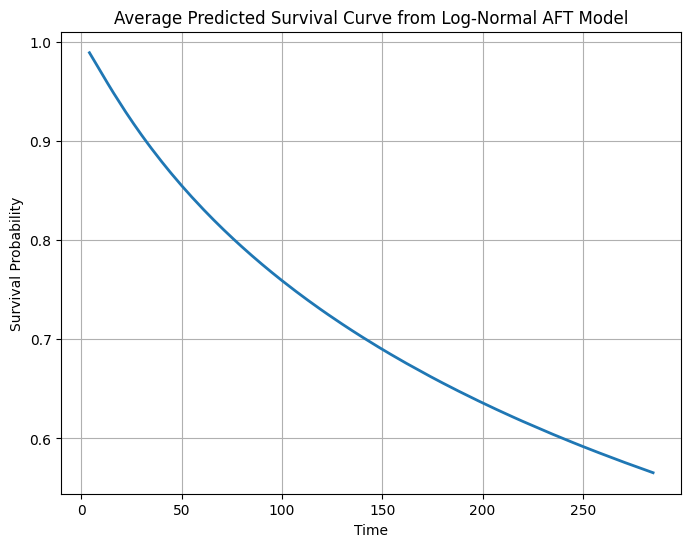

In [15]:
# Predict survival curves for all patients
all_surv = ln_aft.predict_survival_function(aft_data[predictors])

# Average survival probability at each time point
avg_surv = all_surv.mean(axis=1)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(avg_surv.index, avg_surv.values, linewidth=2)
plt.title("Average Predicted Survival Curve from Log-Normal AFT Model")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.savefig("lognormal_aft_average_survival_curve.png", dpi=300, bbox_inches="tight")
plt.show()

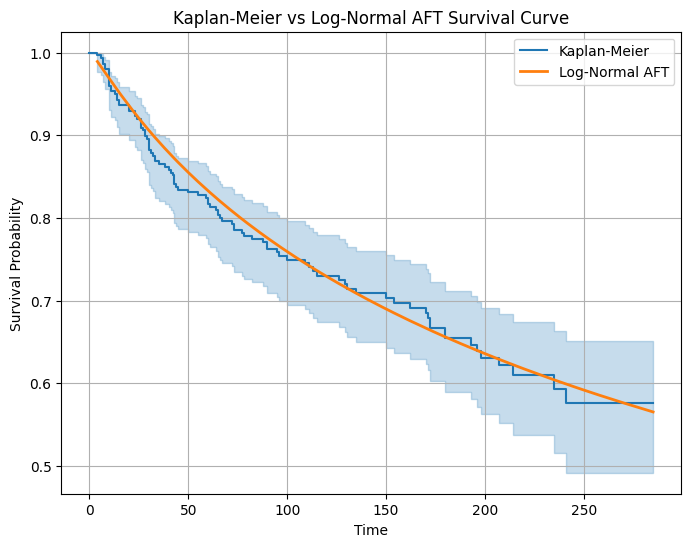

In [ ]:
from lifelines import KaplanMeierFitter

# KM curve
kmf = KaplanMeierFitter()
kmf.fit(aft_data[time_col], event_observed=aft_data[event_col], label="Kaplan-Meier")

# AFT average predicted curve
all_surv = ln_aft.predict_survival_function(aft_data[predictors])
avg_surv = all_surv.mean(axis=1)

# Plot together
plt.figure(figsize=(8, 6))
kmf.plot_survival_function(ci_show=True)
plt.plot(avg_surv.index, avg_surv.values, linewidth=2, label="Log-Normal AFT")

plt.title("Kaplan-Meier vs Log-Normal AFT Survival Curve")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.savefig("km_vs_lognormal_aft.png", dpi=300, bbox_inches="tight")
plt.show()

In [2]:
# =========================================================
# FINAL MODEL DIAGNOSTICS AND COMPARISON
# Standard Cox vs Extended Cox vs AFT Models
# =========================================================

import pandas as pd
import numpy as np

from lifelines import (
    CoxPHFitter,
    WeibullAFTFitter,
    LogNormalAFTFitter,
    LogLogisticAFTFitter
)
from lifelines.utils import concordance_index

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

time_col = "time"
event_col = "DEATH_EVENT"

predictors = [
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking"
]

# ---------------------------------------------------------
# 2. Standard Cox PH Model
# ---------------------------------------------------------
cox_data = df[[time_col, event_col] + predictors].copy()

cph = CoxPHFitter()
cph.fit(cox_data, duration_col=time_col, event_col=event_col)

# ---------------------------------------------------------
# 3. Extended Cox Model with time-dependent terms
# ---------------------------------------------------------
df_ext = df[[time_col, event_col] + predictors].copy()
df_ext["log_time"] = np.log(df_ext[time_col] + 1)

df_ext["ejection_fraction_logt"] = df_ext["ejection_fraction"] * df_ext["log_time"]

ext_predictors = predictors + ["ejection_fraction_logt"]

ext_data = df_ext[[time_col, event_col] + ext_predictors].copy()

cph_ext = CoxPHFitter()
cph_ext.fit(ext_data, duration_col=time_col, event_col=event_col)

# ---------------------------------------------------------
# 4. AFT Models
# ---------------------------------------------------------
aft_data = df[[time_col, event_col] + predictors].copy()

aft_models = {
    "Weibull AFT": WeibullAFTFitter(),
    "Log-Normal AFT": LogNormalAFTFitter(),
    "Log-Logistic AFT": LogLogisticAFTFitter()
}

aft_results = []
fitted_aft = {}

for name, model in aft_models.items():
    model.fit(aft_data, duration_col=time_col, event_col=event_col)
    fitted_aft[name] = model

    pred_median = model.predict_median(aft_data)

    cindex = concordance_index(
        aft_data[time_col],
        pred_median,
        aft_data[event_col]
    )

    aft_results.append({
        "Model": name,
        "Log-Likelihood": model.log_likelihood_,
        "AIC": model.AIC_,
        "C-index": cindex
    })

aft_df = pd.DataFrame(aft_results)

# ---------------------------------------------------------
# 5. Final combined comparison table
# ---------------------------------------------------------
final_comparison = pd.DataFrame([
    {
        "Model": "Standard Cox PH",
        "Log-Likelihood": cph.log_likelihood_,
        "AIC": cph.AIC_partial_,
        "C-index": cph.concordance_index_
    },
    {
        "Model": "Extended Cox PH",
        "Log-Likelihood": cph_ext.log_likelihood_,
        "AIC": cph_ext.AIC_partial_,
        "C-index": cph_ext.concordance_index_
    }
])

final_comparison = pd.concat([final_comparison, aft_df], ignore_index=True)

# ---------------------------------------------------------
# 6. Round results for neat display
# ---------------------------------------------------------
final_comparison["Log-Likelihood"] = final_comparison["Log-Likelihood"].round(4)
final_comparison["AIC"] = final_comparison["AIC"].round(4)
final_comparison["C-index"] = final_comparison["C-index"].round(4)

print("\n===== FINAL MODEL DIAGNOSTIC TABLE =====")
print(final_comparison)

# ---------------------------------------------------------
# 7. Identify best models by each metric
# ---------------------------------------------------------
best_loglik_model = final_comparison.loc[final_comparison["Log-Likelihood"].idxmax(), "Model"]
best_aic_model = final_comparison.loc[final_comparison["AIC"].idxmin(), "Model"]
best_cindex_model = final_comparison.loc[final_comparison["C-index"].idxmax(), "Model"]

print("\n===== BEST MODEL BY METRIC =====")
print("Best by Log-Likelihood :", best_loglik_model)
print("Best by AIC            :", best_aic_model)
print("Best by C-index        :", best_cindex_model)

# ---------------------------------------------------------
# 8. Save outputs
# ---------------------------------------------------------
final_comparison.to_csv("final_model_diagnostics.csv", index=False)

summary_text = []
summary_text.append("Final Model Diagnostic Summary")
summary_text.append("--------------------------------")
summary_text.append(f"Best by Log-Likelihood : {best_loglik_model}")
summary_text.append(f"Best by AIC            : {best_aic_model}")
summary_text.append(f"Best by C-index        : {best_cindex_model}")

with open("final_model_diagnostic_summary.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(summary_text))

print("\nSaved files:")
print("- final_model_diagnostics.csv")
print("- final_model_diagnostic_summary.txt")


===== FINAL MODEL DIAGNOSTIC TABLE =====
              Model  Log-Likelihood        AIC  C-index
0   Standard Cox PH       -468.2279   958.4557   0.7408
1   Extended Cox PH       -301.8372   627.6745   0.9623
2       Weibull AFT       -628.1178  1282.2356   0.7406
3    Log-Normal AFT       -630.6854  1287.3709   0.7420
4  Log-Logistic AFT       -629.7308  1285.4616   0.7399

===== BEST MODEL BY METRIC =====
Best by Log-Likelihood : Extended Cox PH
Best by AIC            : Extended Cox PH
Best by C-index        : Extended Cox PH

Saved files:
- final_model_diagnostics.csv
- final_model_diagnostic_summary.txt
